# 🍓 Taller práctico: análisis estadístico de datos metagenómicos

## Pruebas de hipótesis para comparar grupos de muestras

**Python · Google Colab · 7 episodios · 3 h 06 min con descanso**

¿El microbioma de la raíz de una planta de fresa saludable es distinto del de una planta marchita? Para responder no basta con comparar dos promedios: hay que decidir si la diferencia es mayor que la que produciría el azar. En este taller aprenderás a tomar esa decisión con las pruebas estadísticas más usadas para comparar dos grupos de muestras metagenómicas, y a entender qué supone cada una.

Cada prueba se aplica a **dos casos**: unos datos **simulados**, en los que conocemos la verdad y los supuestos se cumplen, y unos datos **reales**, en los que no. Verlos juntos es la forma más directa de entender qué hace cada prueba y cuándo creerle.

## ¿Para quién es este taller?

Para quien quiera **entender las pruebas estadísticas que se usan para comparar muestras de datos metagenómicos**: qué pregunta responde cada una, qué supone sobre los datos y cómo se interpreta su resultado. Sirve tanto si ya tienes una tabla de conteos y no sabes qué prueba aplicar como si lees artículos sobre microbiomas y quieres entender de dónde salen sus valores p.

No es un taller de bioinformática ni de programación: aquí no se procesan lecturas, y el código ya está escrito y comentado paso a paso. Lo que se trabaja es **el razonamiento estadístico y el análisis de los datos**: qué se hace en cada prueba y por qué.

## Conocimientos previos

Este taller empieza donde terminan estas lecciones de [The Carpentries](https://carpentries.org). No es obligatorio haberlas tomado, pero son el punto de partida recomendado:

| Para entender… | Lección | Qué aporta |
|---|---|---|
| Cómo se obtienen los datos | [Data Processing and Visualization for Metagenomics](https://carpentries-lab.github.io/metagenomics-analysis/), del [taller de metagenómica](https://carpentries-lab.github.io/metagenomics-workshop/) de Carpentries Lab | El camino de las lecturas a la tabla de conteos: control de calidad, asignación taxonómica con Kraken y, en sus episodios [*Diversity Tackled With R*](https://carpentries-lab.github.io/metagenomics-analysis/08-Diversity-tackled-with-R/index.html) y [*Taxonomic Analysis with R*](https://carpentries-lab.github.io/metagenomics-analysis/09-abundance-analyses/index.html), el cálculo y la visualización de la diversidad. |
| El código de Python | [Plotting and Programming in Python](https://swcarpentry.github.io/python-novice-gapminder/), de Software Carpentry | Variables, funciones, bucles `for`, tablas de pandas y gráficos. |
| Las tablas de pandas | [Data Analysis and Visualization in Python for Ecologists](https://datacarpentry.github.io/python-ecology-lesson/), de Data Carpentry. En español: [Análisis y visualización de datos usando Python](https://datacarpentry.github.io/python-ecology-lesson-es/) | Leer archivos CSV, seleccionar filas y columnas, agrupar y combinar tablas. |

La lección de metagenómica termina con las gráficas de diversidad. Este taller continúa con la pregunta que sigue: **¿las diferencias que se ven en esas gráficas son reales o son azar?**

## Objetivos generales

Al terminar el taller podrás:

1. **Formular** la comparación entre dos grupos de muestras como una hipótesis nula y una alternativa.
2. **Explicar** qué es un valor p y construir uno a mano, barajando etiquetas.
3. **Comprobar** los supuestos de una prueba (normalidad, igualdad de varianzas, independencia) antes de aplicarla.
4. **Elegir y aplicar** la prueba adecuada: t de Student, t de Welch, Mann-Whitney, Wilcoxon de rangos con signo, PERMANOVA y PERMDISP.
5. **Interpretar** resultados que no coinciden entre pruebas y decidir cuál es válido.
6. **Reportar** un resultado con su estadístico, su tamaño de efecto y su valor p.

## Índice

| Inicio | Episodio | Pregunta que responde | Datos | Explicación | Ejercicios |
|---|---|---|---|---|---|
| 0:00 | **1. Los datos: un caso real y un caso ideal** | ¿Qué contiene una tabla de conteos metagenómicos y cómo llegó a existir? | Reales y simulados | 25 min | 8 min |
| 0:33 | **2. La lógica de una prueba de hipótesis** | ¿Cómo sé si la diferencia entre dos grupos es mayor que la que produciría el azar? | Simulados y reales | 15 min | 6 min |
| 0:54 | **3. Comparar medias: la prueba t de Student y la de Welch** | ¿Qué supone la prueba t y cómo compruebo esos supuestos? | Simulados y reales | 20 min | 8 min |
| 1:22 | *Descanso* | | | 10 min | |
| 1:32 | **4. Pruebas basadas en rangos: Mann-Whitney y Wilcoxon** | ¿Qué hago cuando los datos no son normales o hay valores atípicos? | Simulados y reales | 15 min | 6 min |
| 1:53 | **5. Un género de interés: ¿es más abundante en un grupo?** | ¿Cómo comparo la abundancia de un taxón entre dos grupos? | Simulados y reales | 10 min | 10 min |
| 2:13 | **6. Comparar la composición completa: PERMANOVA y PERMDISP** | ¿Cómo comparo comunidades enteras y no un solo número por muestra? | Simulados y reales | 25 min | 10 min |
| 2:48 | **7. Cierre: reportar y comparar los dos casos** | ¿Cómo se presentan los resultados de varias pruebas? | Simulados y reales | 10 min | 8 min |
| 3:06 | *Fin* | | | | |

Son 2 h 00 min de explicación y 56 min de ejercicios. Puede darse en una sola sesión con descanso o en dos sesiones: los episodios 1 a 3 (1 h 22 min) y los restantes (1 h 34 min).

Hay **7 ejercicios**, uno por episodio. Cada uno tiene la solución escondida: intenta resolverlo antes de abrirla.

## Los datos: dos casos

**Caso real.** 53 metagenomas de la rizósfera de la fresa, la capa de suelo que rodea las raíces: **35 de plantas saludables** y **18 de plantas no saludables**.

- Un **metagenoma** reúne el ADN de todos los microorganismos de una muestra, secuenciado en millones de fragmentos llamados **lecturas** (secuenciación *shotgun*).
- Cada lectura se clasificó con el programa **Kraken**, que la compara con una base de datos de referencia y le asigna un taxón: reino, filo, género.
- El resultado es una **tabla de conteos**: cuántas lecturas de cada muestra corresponden a cada taxón. Usaremos la tabla resumida por género, con 1 795 géneros entre bacterias y eucariotas.

**Caso ideal.** 60 muestras **simuladas** dentro del cuaderno, 30 por grupo, con las propiedades que piden los libros: grupos del mismo tamaño, valores normales, la misma variabilidad en los dos grupos y una diferencia que nosotros mismos ponemos. No son datos de fresa: son un estudio inventado en el que conocemos la respuesta correcta.

Con los dos casos compararemos los grupos de tres maneras: por su **diversidad** (cuántos taxones hay y qué tan repartidas están las lecturas), por la proporción de **un género de interés** y por su **composición completa**.

## Cómo está organizado cada episodio

1. **Preguntas y objetivos:** qué vas a poder responder y hacer al terminar el episodio.
2. **Explicación paso a paso:** primero qué se hace y por qué; después el código, con un comentario en cada paso. Cada prueba se aplica primero a los datos simulados y luego a los reales.
3. **Para pensar:** una pregunta rápida para predecir el resultado antes de ejecutar la celda.
4. **Ejercicio**, con la solución desplegable.
5. **Puntos clave:** lo que conviene recordar.

## Cómo usar este cuaderno

1. En Google Colab: **Archivo → Subir notebook**, o ábrelo desde GitHub con **Archivo → Abrir notebook → GitHub**.
2. Ejecuta las celdas en orden con **Shift + Enter**. Los datos reales se descargan solos desde GitHub; no hay que subir nada.
3. Solo se usan `numpy`, `pandas`, `scipy` y `matplotlib`, que ya vienen instalados en Colab.

Los datos reales fueron facilitados por la empresa [Solena Ag](https://www.solena.ag) (2023) y están publicados en
[GitHub](https://github.com/CamilaSilva1995/Tesis_Maestria/tree/main/Taller_Practico/datos).

---
## Episodio 1. Los datos: un caso real y un caso ideal

⏱️ **Explicación: 25 min · Ejercicios: 8 min**

> **❓ Preguntas**
> - ¿Qué contiene una tabla de conteos metagenómicos y cómo llegó a existir?
> - ¿Para qué sirve tener, junto a los datos reales, unos datos simulados?
>
> **🎯 Objetivos**
> - Cargar las tablas reales y unirlas por el identificador de la muestra.
> - Aplicar un filtro de calidad y comprobar que las tablas quedaron emparejadas.
> - Calcular el índice de Shannon a partir de una columna de conteos.
> - Construir un conjunto de datos simulado en el que conocemos la verdad.

### 1.1 Preparación

Importamos las librerías y definimos una función para cargar los datos. Si estás en Colab, los
archivos se leen directamente desde GitHub. Si tienes el repositorio en tu computadora, se leen de
la carpeta `datos/`.

In [1]:
# Para que las figuras se dibujen dentro del cuaderno, debajo de la celda que las crea
%matplotlib inline
import numpy as np                                      # arreglos numéricos y números aleatorios
import pandas as pd                                     # tablas de datos (DataFrame)
import matplotlib.pyplot as plt                         # figuras
from scipy import stats                                 # pruebas estadísticas (t, Mann-Whitney, Wilcoxon, etc.)
from scipy.spatial.distance import pdist, squareform    # distancias entre muestras (Episodio 6)

# Carpeta del repositorio de GitHub donde están los archivos CSV de la clase
URL = "https://raw.githubusercontent.com/CamilaSilva1995/Tesis_Maestria/main/Taller_Practico/datos/"

def cargar(nombre):
    "Lee un CSV desde GitHub; si no hay internet, desde la carpeta local datos/."
    try:
        return pd.read_csv(URL + nombre)        # primer intento: descargarlo de GitHub
    except Exception:
        return pd.read_csv("datos/" + nombre)   # si falla, leer la copia local

def formato_p(p):
    "Escribe un valor p con cuatro decimales; los muy pequeños, en notación científica."
    return f"{p:.4f}" if p >= 1e-4 else f"{p:.1e}"

# Tamaño de las figuras y de la letra para todo el cuaderno
plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11})
# Un color fijo por grupo, para que todas las figuras se lean igual
COLORES = {"Saludable": "#F8766D", "No saludable": "#00BFC4"}
GRUPOS = ["Saludable", "No saludable"]                  # el orden de los grupos en las figuras
# Versiones instaladas: conviene anotarlas para poder reproducir los resultados
print("Listo. numpy", np.__version__, "| pandas", pd.__version__, "| scipy", __import__("scipy").__version__)

Listo. numpy 2.5.2 | pandas 3.0.5 | scipy 1.18.1


### 1.2 ¿De dónde salen los datos reales?

Antes de aplicar cualquier prueba conviene saber qué representa cada número. Los datos reales recorrieron este camino:

1. **Muestreo y secuenciación.** De la rizósfera de cada planta se obtuvo el ADN de toda la comunidad microbiana y se secuenció (*shotgun*): millones de lecturas por muestra.
2. **Control de calidad.** Las lecturas de mala calidad se filtraron con fastp.
3. **Asignación taxonómica.** Kraken comparó cada lectura con una base de datos de referencia y le asignó un taxón.
4. **Tabla de conteos.** Se contó cuántas lecturas de cada muestra cayeron en cada taxón.
5. **Diversidad alfa.** Con phyloseq se calcularon índices que resumen cada muestra en un número.

Ese camino no se repite aquí: está explicado paso a paso en la lección [*Data Processing and Visualization for Metagenomics*](https://carpentries-lab.github.io/metagenomics-analysis/) de The Carpentries. Este taller **empieza donde aquella termina**, con las tablas ya hechas, y se ocupa de lo que sigue: decidir si los grupos difieren.

De ese camino hay tres cosas que afectan a la estadística y conviene tener presentes:

- Los conteos dependen de **cuántas lecturas** tuvo cada muestra (la profundidad de secuenciación). Por eso se comparan proporciones e índices, no conteos crudos.
- Las proporciones de una muestra **suman 100 %**: si un taxón sube, los demás bajan. Se dice que los datos son *composicionales*.
- Kraken solo reconoce lo que está en su base de datos de referencia.

### 1.3 El caso real: tres tablas

- **`metadatos.csv`**: una fila por muestra, con su grupo (`Saludable` o `No saludable`) y el número de lecturas que Kraken logró clasificar.
- **`diversidad_alfa.csv`**: para cada muestra, cuatro índices de diversidad alfa calculados con phyloseq sobre los 9 003 taxones de la tabla original: riqueza observada, Chao1, Shannon y Simpson.
- **`conteos_por_genero.csv`**: cuántas lecturas de cada muestra se asignaron a cada género. Hay 1 795 géneros (1 737 bacterianos y 58 eucariotas).

Cada muestra tiene un identificador como `MD2055` o `MP2099`. **Ese identificador es la llave que une las tres tablas.** Lo repetiremos varias veces: nunca se unen tablas «por posición», siempre por identificador.

In [2]:
# set_index("muestra") pone el identificador de la muestra como índice (la etiqueta de cada fila):
# así las tablas se unen por identificador y no por posición
meta  = cargar("metadatos.csv").set_index("muestra")          # grupo y lecturas clasificadas de cada muestra
alfa  = cargar("diversidad_alfa.csv").set_index("muestra")    # índices de diversidad alfa de cada muestra
conteos = cargar("conteos_por_genero.csv")                    # una fila por género y una columna por muestra

print("Muestras en metadatos:", len(meta))
# display() muestra la tabla con formato; head() devuelve solo las cinco primeras filas
display(meta.head())
display(alfa.head())
display(conteos.iloc[:5, :8])   # primeras filas y columnas de la tabla de géneros

Muestras en metadatos: 58


,tratamiento,grupo,lecturas_clasificadas
muestra,,,
MD2055,wilted,No saludable,9782432
MD2056,wilted,No saludable,12468526
MD2065,wilted,No saludable,11297600
MD2066,wilted,No saludable,15580959
MD2075,wilted,No saludable,12310781


,observados,chao1,shannon,simpson
muestra,,,,
MD2055,8574,8720.286,7.466004,0.997774
MD2056,8654,8789.198,7.485615,0.997892
MD2065,8550,8744.387,7.318039,0.997244
MD2066,8706,8784.103,7.506399,0.997941
MD2075,8687,8811.039,7.437571,0.997770


,reino,filo,genero,MD2055,MD2056,MD2065,MD2066,MD2075
0,Bacteria,NaN,Candidatus Babela,28,41,19,49,47
1,Bacteria,NaN,Candidatus Chazhemtobacterium,38,58,28,61,58
2,Bacteria,Acidobacteria,Acidisarcina,1904,2351,1588,2932,1511
3,Bacteria,Acidobacteria,Acidobacterium,5478,6791,4553,8200,4130
4,Bacteria,Acidobacteria,Candidatus Koribacter,5478,6813,4506,8157,4177


**El filtro de calidad.** Se descartan las muestras que, después del control de calidad con fastp, tenían **menos de 25 millones de lecturas**. Son cinco: `MP2079`, `MP2080`, `MP2088`, `MP2109` y `MP2137`. La más extrema, `MP2088`, conservó solo dos lecturas. Aplicamos ese filtro y unimos las tablas por identificador.

In [3]:
# Las cinco muestras con menos de 25 millones de lecturas tras el control de calidad
excluir = ["MP2079", "MP2080", "MP2088", "MP2109", "MP2137"]

# how="inner" conserva solo las muestras que aparecen en las dos tablas
datos = meta.join(alfa, how="inner")          # une por el índice 'muestra'
datos = datos.drop(index=excluir)             # quita las cinco filas descartadas
muestras = list(datos.index)                  # las 53 muestras reales que usaremos en todo el taller

# dejamos la tabla de géneros con las mismas muestras y en el MISMO orden que 'datos'
# (reino, filo y género pasan al índice; las columnas que quedan son las muestras)
generos = conteos.set_index(["reino", "filo", "genero"])[muestras]

print("Muestras tras el filtro:", len(datos))
print(datos.grupo.value_counts())             # cuántas muestras quedan en cada grupo
# assert detiene la ejecución con un error si la condición no se cumple
assert list(generos.columns) == muestras      # comprobación: mismo orden en las dos tablas

Muestras tras el filtro: 53
grupo
Saludable       35
No saludable    18
Name: count, dtype: int64


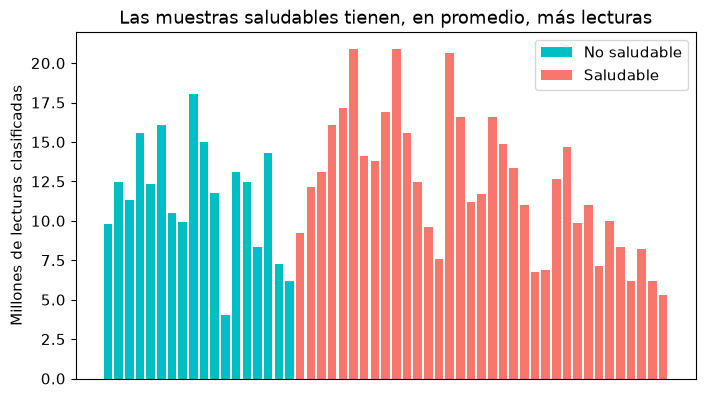

grupo
No saludable    11582705.0
Saludable       12241645.0
Name: lecturas_clasificadas, dtype: float64


In [4]:
# Lecturas clasificadas por muestra: ¿hay diferencia de profundidad entre grupos?
fig, ax = plt.subplots()   # una figura (fig) con un solo panel (ax)
# groupby recorre los grupos: g es el nombre del grupo y sub, la tabla con sus muestras
for g, sub in datos.groupby("grupo"):
    ax.bar(sub.index, sub.lecturas_clasificadas / 1e6, color=COLORES[g], label=g)   # 1e6: pasa a millones
ax.set_ylabel("Millones de lecturas clasificadas"); ax.set_xticks([])   # sin marcas en x: 53 nombres no caben
ax.set_title("Las muestras saludables tienen, en promedio, más lecturas"); ax.legend()
plt.show()
# Promedio de lecturas clasificadas en cada grupo
print(datos.groupby("grupo").lecturas_clasificadas.mean().round(0))

Los grupos no tienen la misma profundidad. Si comparáramos conteos crudos, esa diferencia técnica se confundiría con una diferencia biológica; por eso de aquí en adelante trabajamos con **proporciones** y con índices.

### 1.4 De una columna de conteos a un número: el índice de Shannon

El índice de Shannon de una muestra es $H = -\sum_i p_i \ln p_i$, donde $p_i$ es la proporción de lecturas del taxón $i$. Resume en un número la riqueza (cuántos taxones hay) y la equidad (qué tan repartidas están las lecturas). Ya está calculado en la columna `shannon`; comprobemos la fórmula con una muestra usando la tabla de géneros.

In [5]:
def shannon(conteos):
    "Índice de Shannon, H = -sum(p_i ln p_i), a partir de los conteos de una muestra."
    p = conteos / conteos.sum()      # de conteos a proporciones p_i
    p = p[p > 0]                     # sin los ceros: ln(0) no está definido
    return -(p * np.log(p)).sum()    # H = -sum(p_i ln p_i)

# generos["MD2055"] es la columna con los conteos de esa muestra
print("Shannon de MD2055 sobre la tabla de géneros:", round(shannon(generos["MD2055"]), 3))
print("Shannon de MD2055 sobre los 9 003 taxones (phyloseq):", datos.loc["MD2055", "shannon"].round(3))
print("Son distintos porque la tabla de géneros agrupa taxones; la columna 'shannon' se calculó con la tabla completa.")

Shannon de MD2055 sobre la tabla de géneros: 5.069
Shannon de MD2055 sobre los 9 003 taxones (phyloseq): 7.466
Son distintos porque la tabla de géneros agrupa taxones; la columna 'shannon' se calculó con la tabla completa.


### 1.5 El caso ideal: datos simulados

Los datos reales rara vez se portan como piden los libros. Para ver cómo funciona cada prueba **cuando todo se cumple**, fabricamos un segundo estudio en el que nosotros decidimos la verdad:

- **Diseño balanceado:** 30 plantas saludables y 30 no saludables.
- **Diversidad:** el índice de Shannon sigue una distribución **normal**, con la **misma desviación estándar** (0.05) en los dos grupos y medias distintas: 7.48 en las saludables y 7.42 en las no saludables. Son las medias que se observan en los datos reales, así que la diferencia verdadera es 0.06.
- **Composición:** 40 géneros. En las plantas no saludables un género, `G05`, es cuatro veces más abundante. La variabilidad entre muestras es la misma en los dos grupos.

Como conocemos la verdad, sabremos si cada prueba acierta. Empezamos por el índice de diversidad.

In [6]:
rng_sim = np.random.default_rng(2026)          # generador aleatorio con semilla: todos obtenemos los mismos datos
n_sim = 30                                     # muestras por grupo: diseño balanceado

# La verdad que elegimos: medias distintas, misma desviación estándar, distribución normal
media_sal, media_no, desviacion = 7.48, 7.42, 0.05

# Identificadores: S01...S30 para las saludables y N01...N30 para las no saludables
ids = [f"S{i:02d}" for i in range(1, n_sim + 1)] + [f"N{i:02d}" for i in range(1, n_sim + 1)]
datos_sim = pd.DataFrame({
    "grupo": ["Saludable"] * n_sim + ["No saludable"] * n_sim,
    # rng_sim.normal(media, desviación, cuántos): valores al azar de una distribución normal
    "shannon": np.concatenate([rng_sim.normal(media_sal, desviacion, n_sim),
                               rng_sim.normal(media_no, desviacion, n_sim)]),
}, index=pd.Index(ids, name="muestra"))

# Lo que salió en estas 60 muestras: se parece a la verdad, pero no es idéntico
display(datos_sim.groupby("grupo").shannon.agg(["count", "mean", "std"]).round(3))

,count,mean,std
grupo,,,
No saludable,30,7.443,0.055
Saludable,30,7.480,0.040


La verdad es una diferencia de 0.06; en estas 60 muestras se observa una de 0.037. Esa distancia entre la verdad y lo observado es la **variación de muestreo**, y es justo lo que una prueba de hipótesis tiene que tener en cuenta.

Ahora la tabla de géneros. Cada muestra se genera en tres pasos: se parte de la composición promedio de su grupo, cada género se desvía al azar de ese promedio y, por último, se «secuencian» 100 000 lecturas.

In [7]:
n_generos, lecturas_sim, variabilidad = 40, 100_000, 0.25
nombres = [f"G{i:02d}" for i in range(1, n_generos + 1)]        # G01, G02, ..., G40
patogeno = "G05"                                                 # el género que haremos más abundante

# Composición promedio de una planta saludable: pocos géneros abundantes y muchos escasos
comp_sal = pd.Series(1 / np.arange(1, n_generos + 1), index=nombres)
comp_sal = comp_sal / comp_sal.sum()                             # proporciones que suman 1
# En las no saludables el patógeno es 4 veces más abundante; después se vuelve a normalizar
comp_no = comp_sal.copy()
comp_no[patogeno] = 4 * comp_no[patogeno]
comp_no = comp_no / comp_no.sum()

def simular_muestras(composicion, n_muestras):
    "Simula n_muestras columnas de conteos alrededor de una composición promedio."
    columnas = []
    for _ in range(n_muestras):
        # paso 1 y 2: cada género se desvía al azar de su promedio (la misma variabilidad en los dos grupos)
        p = composicion.to_numpy() * np.exp(rng_sim.normal(0, variabilidad, len(composicion)))
        p = p / p.sum()                                          # las proporciones vuelven a sumar 1
        # paso 3: se reparten 100 000 lecturas entre los géneros según esas proporciones
        columnas.append(rng_sim.multinomial(lecturas_sim, p))
    return np.array(columnas).T                                  # filas = géneros, columnas = muestras

# 30 columnas de cada grupo, una al lado de la otra, con los mismos identificadores que datos_sim
generos_sim = pd.DataFrame(np.hstack([simular_muestras(comp_sal, n_sim), simular_muestras(comp_no, n_sim)]),
                           index=pd.Index(nombres, name="genero"), columns=datos_sim.index)
assert list(generos_sim.columns) == list(datos_sim.index)        # emparejadas por identificador
display(generos_sim.iloc[:6, :5])                                # primeros géneros y primeras muestras

muestra,S01,S02,S03,S04,S05
genero,,,,,
G01,20423,28355,21569,14893,27704
G02,10161,10972,10523,19174,13001
G03,6850,3045,8058,9066,9073
G04,4583,6593,6631,7181,6519
G05,4247,4828,4373,4516,4265
G06,6044,3630,3750,2723,3233


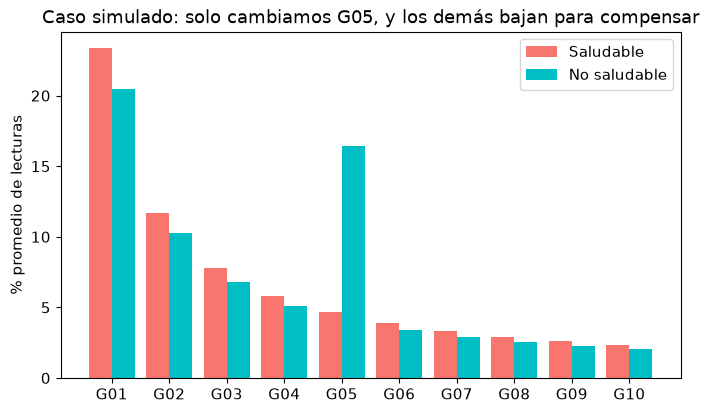

In [8]:
# La verdad que simulamos: composición promedio de los diez géneros más abundantes en cada grupo
fig, ax = plt.subplots()
pos = np.arange(10)                                              # posición de cada par de barras
ax.bar(pos - 0.2, 100 * comp_sal.iloc[:10], width=0.4, color=COLORES["Saludable"], label="Saludable")
ax.bar(pos + 0.2, 100 * comp_no.iloc[:10], width=0.4, color=COLORES["No saludable"], label="No saludable")
ax.set_xticks(pos, nombres[:10]); ax.set_ylabel("% promedio de lecturas")
ax.set_title("Caso simulado: solo cambiamos G05, y los demás bajan para compensar")
ax.legend(); plt.show()

En la figura está la verdad que elegimos: `G05` pasa de cerca del 5 % al 16 % de las lecturas. Los demás géneros bajan un poco aunque no los tocamos: es la composicionalidad en acción.

### ✏️ Ejercicio 1: Conocer los datos

⏱️ *8 min*

Con las tablas ya cargadas, responde con código:

1. ¿Cuántos géneros de eucariotas hay en `generos`? ¿Y cuántos de bacterias?
2. ¿Cuál es el género con más lecturas en total? ¿De qué filo es?
3. ¿Por qué el filtro de calidad eliminó solo muestras saludables? Mira `meta.loc[excluir]`.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. Hay 58 géneros de eucariotas y 1 737 de bacterias. Los eucariotas están subrepresentados en la base de datos de Kraken, no necesariamente en el suelo.
2. *Streptomyces* (Actinobacteria), con diferencia. Es el género más abundante de la rizósfera de fresa en estos datos.
3. Las cinco muestras excluidas estaban etiquetadas como saludables. El filtro no «elige» grupo: simplemente esas cinco tuvieron pocas lecturas. Por eso el grupo saludable pasó de 40 a 35 muestras y el no saludable se quedó en 18.

```python
# 1. Géneros por reino: reset_index devuelve 'reino' a una columna para poder contarlo
print(generos.reset_index().reino.value_counts())
# 2. Lecturas totales de cada género (suma por fila, axis=1), de mayor a menor
total = generos.sum(axis=1).sort_values(ascending=False)
print(total.head(3))
# 3. Metadatos de las cinco muestras excluidas: mira la columna grupo
print(meta.loc[excluir])
```

</details>

> **🔑 Puntos clave**
> - Una tabla de conteos dice cuántas lecturas de cada muestra se asignaron a cada taxón; llega después del control de calidad y de la asignación taxonómica.
> - Las tablas se unen por el identificador de la muestra, nunca por posición, y se comprueba con `assert`.
> - El índice de Shannon resume en un número la riqueza y la equidad de una muestra.
> - En los datos simulados conocemos la verdad porque la elegimos: sirven para ver cómo se comporta una prueba cuando sus supuestos se cumplen.

---
## Episodio 2. La lógica de una prueba de hipótesis

⏱️ **Explicación: 15 min · Ejercicios: 6 min**

> **❓ Preguntas**
> - ¿Cómo sé si la diferencia entre dos grupos es mayor que la que produciría el azar?
> - ¿Qué es exactamente un valor p?
>
> **🎯 Objetivos**
> - Formular la hipótesis nula de una comparación entre dos grupos.
> - Construir a mano la distribución bajo la hipótesis nula barajando las etiquetas de grupo.
> - Calcular e interpretar un valor p por permutaciones.

Antes de usar ninguna fórmula, hagamos el razonamiento a mano.

**Qué hacemos.** Comparamos el índice de Shannon promedio de los dos grupos y preguntamos: **¿la diferencia observada es más grande de lo que se obtendría por puro azar?**

**Por qué así.** La **hipótesis nula** $H_0$ dice que el grupo no importa: la etiqueta «saludable» o «no saludable» es intercambiable. Si eso fuera cierto, podríamos **barajar las etiquetas** entre las muestras y la diferencia de medias cambiaría solo por azar. Repitiendo la barajada 5 000 veces obtenemos la distribución de la diferencia bajo $H_0$. El **valor p** es la fracción de barajadas que producen una diferencia tan grande, o más, que la observada.

Este razonamiento por permutaciones es exactamente el que usa el PERMANOVA en el Episodio 6.

### 2.1 Caso ideal: paso a paso con los datos simulados

Empezamos donde sabemos que la diferencia existe.

In [9]:
# Shannon de cada grupo como arreglo de numpy: x_sim = saludables (30), y_sim = no saludables (30)
x_sim = datos_sim.loc[datos_sim.grupo == "Saludable", "shannon"].to_numpy()
y_sim = datos_sim.loc[datos_sim.grupo == "No saludable", "shannon"].to_numpy()
dif_sim = x_sim.mean() - y_sim.mean()                    # la diferencia que vemos en estas muestras
print(f"Media saludable = {x_sim.mean():.3f}   Media no saludable = {y_sim.mean():.3f}   Diferencia = {dif_sim:.3f}")

rng = np.random.default_rng(2026)                        # generador aleatorio con semilla: el resultado se repite
todos = np.concatenate([x_sim, y_sim])                   # los 60 valores juntos, sin etiqueta de grupo
barajadas_sim = []                                       # aquí se guarda la diferencia de cada barajada
for _ in range(5000):
    rng.shuffle(todos)                                   # barajar etiquetas
    # los primeros 30 valores hacen de "saludables" y los 30 restantes, de "no saludables"
    barajadas_sim.append(todos[:len(x_sim)].mean() - todos[len(x_sim):].mean())
barajadas_sim = np.array(barajadas_sim)                  # de lista a arreglo, para operar con todas a la vez

# valor p: fracción de barajadas con una diferencia al menos tan grande como la observada
extremas = np.abs(barajadas_sim) >= abs(dif_sim)         # bilateral: cuenta en los dos sentidos
p_perm_sim = np.mean(extremas)
print(f"De 5 000 barajadas, {extremas.sum()} igualan o superan la diferencia observada: p = {p_perm_sim:.4f}")

Media saludable = 7.480   Media no saludable = 7.443   Diferencia = 0.037
De 5 000 barajadas, 29 igualan o superan la diferencia observada: p = 0.0058


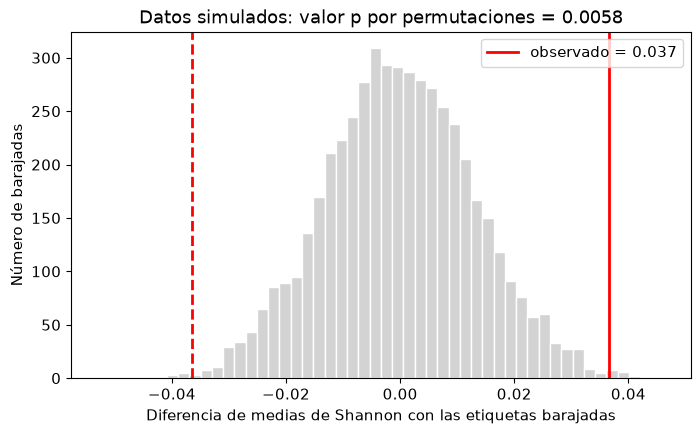

In [10]:
def grafica_nula(nulos, observado, etiqueta_x, titulo, bilateral=True):
    "Histograma de un estadístico con las etiquetas barajadas (H0) y, en rojo, el valor observado."
    fig, ax = plt.subplots()
    ax.hist(nulos, bins=50, color="lightgray", edgecolor="white")
    ax.axvline(observado, color="red", lw=2, label=f"observado = {observado:.3f}")
    if bilateral:                                        # en una prueba bilateral cuenta también el lado contrario
        ax.axvline(-observado, color="red", lw=2, ls="--")
    ax.set_xlabel(etiqueta_x); ax.set_ylabel("Número de barajadas")
    ax.set_title(titulo); ax.legend(); plt.show()

grafica_nula(barajadas_sim, dif_sim, "Diferencia de medias de Shannon con las etiquetas barajadas",
             f"Datos simulados: valor p por permutaciones = {p_perm_sim:.4f}")

**Lee la figura.** El histograma gris es lo que produce el azar cuando el grupo no importa. Las líneas rojas marcan la diferencia observada, en los dos sentidos porque la prueba es bilateral. Muy pocas barajadas llegan tan lejos: $p \approx 0.006$. Con $\alpha = 0.05$ rechazamos $H_0$ y, como aquí conocemos la verdad, sabemos que la prueba acertó.

> 💬 **Para pensar (1 min).** En los datos reales la diferencia observada entre las medias es 0.061, **mayor** que la de los datos simulados (0.037). ¿Esperas un valor p más pequeño? Anota tu predicción antes de ejecutar la celda siguiente.

### 2.2 Caso real: los mismos pasos, guardados en una función

Para no copiar el código, lo guardamos en una función y la aplicamos a los datos reales.

Media saludable = 7.478   Media no saludable = 7.417   Diferencia = 0.061


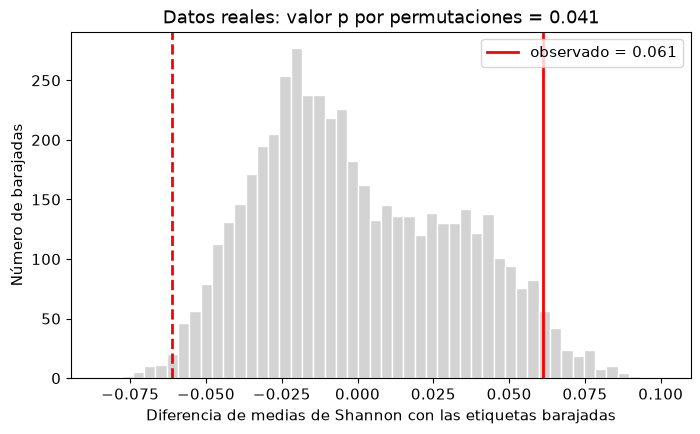

In [11]:
def prueba_permutacion(x, y, n_perm=5000, semilla=2026):
    "Los pasos de la celda anterior en una función: devuelve la diferencia observada, las barajadas y el valor p."
    rng = np.random.default_rng(semilla)
    observada = x.mean() - y.mean()
    todos = np.concatenate([x, y])                       # todos los valores, sin etiqueta de grupo
    barajadas = []
    for _ in range(n_perm):
        rng.shuffle(todos)                               # barajar etiquetas
        barajadas.append(todos[:len(x)].mean() - todos[len(x):].mean())
    barajadas = np.array(barajadas)
    return observada, barajadas, np.mean(np.abs(barajadas) >= abs(observada))

# Shannon de cada grupo en los datos reales: x = saludables (35), y = no saludables (18)
x = datos.loc[datos.grupo == "Saludable", "shannon"].to_numpy()
y = datos.loc[datos.grupo == "No saludable", "shannon"].to_numpy()
dif_real, barajadas_real, p_perm_real = prueba_permutacion(x, y)
print(f"Media saludable = {x.mean():.3f}   Media no saludable = {y.mean():.3f}   Diferencia = {dif_real:.3f}")

grafica_nula(barajadas_real, dif_real, "Diferencia de medias de Shannon con las etiquetas barajadas",
             f"Datos reales: valor p por permutaciones = {p_perm_real:.3f}")

**Lee la figura.** Solo un 4 % de las barajadas supera la diferencia observada: $p \approx 0.04$. Es significativo, pero bastante menos contundente que en los datos simulados, a pesar de que la diferencia observada es mayor. El valor p no depende solo de la diferencia: depende también de **cuánto varían los datos** y de **cuántas muestras hay**. En los datos reales el grupo no saludable tiene 18 muestras y es muy variable.

**Guarda ese 0.04.** En el siguiente episodio otras pruebas sobre los mismos datos darán $p = 0.058$, $0.15$ y $0.26$, y entenderemos por qué: cada prueba hace supuestos distintos. El de barajar etiquetas es que, bajo $H_0$, los dos grupos tienen la misma distribución, **varianza incluida**. Fíjate en que el histograma de los datos reales es asimétrico: hay una planta no saludable con un Shannon muy bajo que arrastra la media del grupo en el que cae en cada barajada. Es una pista de que los dos grupos no se comportan igual.

Tres ideas que vale la pena fijar:

- Un valor p **no** es la probabilidad de que $H_0$ sea cierta. Es la probabilidad de ver un resultado así de extremo *si* $H_0$ fuera cierta.
- Un p mayor que 0.05 **no demuestra** que los grupos sean iguales. Solo dice que no tenemos evidencia suficiente para distinguirlos.
- El umbral $\alpha = 0.05$ se fija **antes** de mirar los datos.

### ✏️ Ejercicio 2: Interpretar el valor p

⏱️ *6 min*

1. Si repitiéramos las 5 000 barajadas con otra semilla, ¿el valor p sería exactamente el mismo? ¿Por qué?
2. Un compañero dice: «p = 0.15 significa que hay 15 % de probabilidad de que los grupos sean iguales». ¿Qué está mal?
3. Con código: repite la prueba sobre los datos simulados usando solo las **cinco primeras muestras** de cada grupo, `prueba_permutacion(x_sim[:5], y_sim[:5])`. La diferencia verdadera sigue siendo la misma. ¿Qué pasa con el valor p y por qué?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. No exactamente. El valor p por permutaciones es una estimación de Monte Carlo: cambia un poco con la semilla. Con 5 000 barajadas la variación es de unas milésimas; con 99 barajadas sería mucho mayor. Por eso se reporta el número de permutaciones.
2. Confunde $P(\text{datos} \mid H_0)$ con $P(H_0 \mid \text{datos})$. El valor p se calcula suponiendo que $H_0$ es cierta; no dice nada sobre la probabilidad de $H_0$.
3. Con cinco muestras por grupo el valor p sube y deja de ser significativo, aunque la diferencia verdadera no cambió. Con pocas muestras el promedio de cada grupo varía mucho de una barajada a otra, la distribución bajo $H_0$ se ensancha y la diferencia observada ya no queda en la cola. La significancia depende del tamaño de muestra tanto como del tamaño del efecto: no detectar una diferencia no demuestra que no exista.

```python
# [2] es el tercer resultado de la función: el valor p
dif5, _, p5 = prueba_permutacion(x_sim[:5], y_sim[:5])
print(f"Con 5 muestras por grupo: diferencia = {dif5:.3f}, p = {p5:.3f}")
print(f"Con 30 muestras por grupo: diferencia = {dif_sim:.3f}, p = {p_perm_sim:.4f}")
```

</details>

> **🔑 Puntos clave**
> - La hipótesis nula dice que el grupo no importa: las etiquetas son intercambiables.
> - El valor p es la fracción de resultados que, si la hipótesis nula fuera cierta, serían al menos tan extremos como el observado. No es la probabilidad de que la hipótesis nula sea cierta.
> - Barajar las etiquetas construye la distribución bajo la hipótesis nula sin usar fórmulas, pero supone que los grupos tendrían la misma distribución, varianza incluida.
> - El valor p depende de la diferencia, de la variabilidad y del tamaño de muestra; un p grande no demuestra que los grupos sean iguales.

---
## Episodio 3. Comparar medias: la prueba t de Student y la de Welch

⏱️ **Explicación: 20 min · Ejercicios: 8 min**

> **❓ Preguntas**
> - ¿Qué supone la prueba t y cómo compruebo esos supuestos?
> - ¿Qué cambia cuando las varianzas de los grupos son distintas?
>
> **🎯 Objetivos**
> - Comprobar la normalidad con Shapiro-Wilk y la igualdad de varianzas con la prueba F.
> - Aplicar la prueba t de Student y la de Welch y decidir cuál corresponde.
> - Explicar por qué las dos versiones coinciden en el caso ideal y difieren en el caso real.

**Qué hacemos.** La **prueba t** compara las medias de dos grupos. Su hipótesis nula es $H_0: \mu_{\text{sal}} = \mu_{\text{no sal}}$ y su estadístico es la diferencia de medias medida en unidades de su error estándar:

$$t = \frac{\bar{x} - \bar{y}}{\text{error estándar de la diferencia}}$$

Es la misma idea del episodio anterior, con un cambio: en lugar de barajar, la distribución bajo $H_0$ sale de una fórmula, la distribución t. Esa fórmula solo vale si se cumplen ciertos **supuestos**.

**Por qué hay dos versiones.** Difieren en cómo calculan el error estándar:

- **Student (varianzas iguales):** combina las dos varianzas en una sola y usa $n_1 + n_2 - 2$ grados de libertad.
- **Welch (varianzas distintas):** usa cada varianza por separado y corrige los grados de libertad.

Las dos suponen que cada grupo es aproximadamente **normal** y que las muestras son **independientes**. Por eso, antes de aplicar la prueba, se comprueban los supuestos: la normalidad con **Shapiro-Wilk** y la igualdad de varianzas con la **prueba F**.

### 3.1 Caso ideal: los supuestos se cumplen

In [12]:
print("Desviación estándar de Shannon en los datos simulados:")
print(datos_sim.groupby("grupo").shannon.std().round(3))

# Normalidad en cada grupo (Shapiro-Wilk): H0 = los datos son normales
for g, v in [("Saludable", x_sim), ("No saludable", y_sim)]:
    W, p_sw = stats.shapiro(v)   # W cerca de 1 = compatible con la normalidad; p pequeño = se rechaza
    print(f"Shapiro-Wilk {g:13s}: W = {W:.3f}, p = {p_sw:.4f}")

# Igualdad de varianzas (prueba F): H0 = sigma1^2 = sigma2^2
F_sim = x_sim.var(ddof=1) / y_sim.var(ddof=1)     # cociente de varianzas muestrales (ddof=1 divide entre n - 1)
gl1, gl2 = len(x_sim) - 1, len(y_sim) - 1         # grados de libertad del numerador y del denominador
# valor p bilateral: el doble de la cola más pequeña de la distribución F
p_F_sim = 2 * min(stats.f.cdf(F_sim, gl1, gl2), 1 - stats.f.cdf(F_sim, gl1, gl2))
print(f"\nPrueba F: F = {F_sim:.3f} con ({gl1}, {gl2}) gl, p = {p_F_sim:.4f}")

Desviación estándar de Shannon en los datos simulados:
grupo
No saludable    0.055
Saludable       0.040
Name: shannon, dtype: float64
Shapiro-Wilk Saludable    : W = 0.980, p = 0.8372
Shapiro-Wilk No saludable : W = 0.951, p = 0.1853

Prueba F: F = 0.550 con (29, 29) gl, p = 0.1128


Ninguna de las dos pruebas rechaza su hipótesis nula: los grupos son compatibles con una distribución normal y con varianzas iguales. Las desviaciones muestrales no son idénticas (0.040 y 0.055) aunque la verdadera es 0.05 en los dos grupos: es variación de muestreo, y la prueba F no la distingue del azar. Corresponde la t de Student; calculamos también la de Welch para compararlas.

In [13]:
# equal_var=True es la t clásica de Student; equal_var=False es la de Welch
t_student_sim = stats.ttest_ind(x_sim, y_sim, equal_var=True)
t_welch_sim = stats.ttest_ind(x_sim, y_sim, equal_var=False)

def gl_welch(x, y):
    "Grados de libertad de la prueba de Welch (fórmula de Welch-Satterthwaite)."
    vx, vy = x.var(ddof=1) / len(x), y.var(ddof=1) / len(y)   # s^2 / n de cada grupo: la varianza de su media
    return (vx + vy) ** 2 / (vx ** 2 / (len(x) - 1) + vy ** 2 / (len(y) - 1))

print(f"t de Student: t = {t_student_sim.statistic:.3f}, gl = {len(x_sim) + len(y_sim) - 2}, p = {t_student_sim.pvalue:.4f}")
print(f"t de Welch:   t = {t_welch_sim.statistic:.3f}, gl = {gl_welch(x_sim, y_sim):.1f}, p = {t_welch_sim.pvalue:.4f}")

t de Student: t = 2.949, gl = 58, p = 0.0046
t de Welch:   t = 2.949, gl = 53.5, p = 0.0047


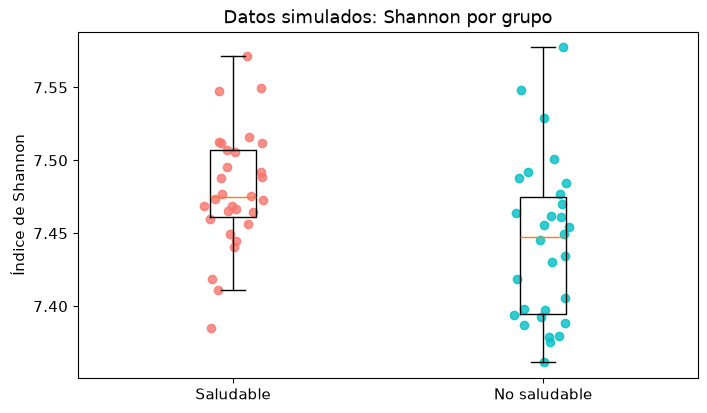

In [14]:
def grafica_cajas(x, y, etiqueta_y, titulo, semilla=1):
    "Diagrama de caja de los dos grupos con el punto de cada muestra encima."
    rng = np.random.default_rng(semilla)                # solo para separar los puntos horizontalmente
    fig, ax = plt.subplots()
    # showfliers=False: los atípicos no se marcan aparte, porque ya se dibujan todos los puntos
    ax.boxplot([x, y], showfliers=False)
    ax.set_xticks([1, 2], GRUPOS)                       # nombre de cada caja (posiciones 1 y 2)
    # i = 1, 2 es la posición de cada caja; el desplazamiento al azar evita que los puntos se tapen
    for i, (v, g) in enumerate(zip([x, y], GRUPOS), 1):
        ax.scatter(i + rng.uniform(-0.1, 0.1, len(v)), v, color=COLORES[g], alpha=0.8)
    ax.set_ylabel(etiqueta_y); ax.set_title(titulo); plt.show()

grafica_cajas(x_sim, y_sim, "Índice de Shannon", "Datos simulados: Shannon por grupo")

Las dos versiones dan prácticamente lo mismo ($p \approx 0.005$) y coinciden con el valor p por permutaciones del episodio anterior. **Cuando los supuestos se cumplen, las pruebas cuentan la misma historia.**

> 💬 **Para pensar (1 min).** En los datos reales hay una planta no saludable con un Shannon muy bajo. ¿Qué supuesto crees que va a fallar? ¿Cambiará eso el valor p?

### 3.2 Caso real: los supuestos fallan

Reunimos todos los pasos en una función y la aplicamos a los dos casos para verlos lado a lado.

In [15]:
def comparar_medias(x, y):
    "Supuestos y las dos versiones de la prueba t para dos grupos: devuelve una columna de resultados."
    F = x.var(ddof=1) / y.var(ddof=1)
    cola = stats.f.cdf(F, len(x) - 1, len(y) - 1)       # probabilidad a la izquierda de F
    student = stats.ttest_ind(x, y, equal_var=True)
    welch = stats.ttest_ind(x, y, equal_var=False)
    return {
        "Muestras (saludable, no saludable)":         f"{len(x)}, {len(y)}",
        "Media (saludable, no saludable)":            f"{x.mean():.3f}, {y.mean():.3f}",
        "Desv. estándar (saludable, no saludable)":   f"{x.std(ddof=1):.3f}, {y.std(ddof=1):.3f}",
        "Shapiro-Wilk, saludable: p":                 formato_p(stats.shapiro(x).pvalue),
        "Shapiro-Wilk, no saludable: p":              formato_p(stats.shapiro(y).pvalue),
        "Prueba F de varianzas: F":                   f"{F:.3f}",
        "Prueba F de varianzas: p":                   formato_p(2 * min(cola, 1 - cola)),
        "t de Student: t (gl)":                       f"{student.statistic:.3f} ({len(x) + len(y) - 2})",
        "t de Student: p":                            formato_p(student.pvalue),
        "t de Welch: t (gl)":                         f"{welch.statistic:.3f} ({gl_welch(x, y):.1f})",
        "t de Welch: p":                              formato_p(welch.pvalue),
    }

# Una columna por caso: las filas quedan alineadas porque las dos columnas tienen los mismos nombres
display(pd.DataFrame({"Datos simulados": comparar_medias(x_sim, y_sim), "Datos reales": comparar_medias(x, y)}))

,Datos simulados,Datos reales
"Muestras (saludable, no saludable)","30, 30","35, 18"
"Media (saludable, no saludable)","7.480, 7.443","7.478, 7.417"
"Desv. estándar (saludable, no saludable)","0.040, 0.055","0.061, 0.168"
"Shapiro-Wilk, saludable: p",0.8372,0.1300
"Shapiro-Wilk, no saludable: p",0.1853,9.0e-06
Prueba F de varianzas: F,0.550,0.132
Prueba F de varianzas: p,0.1128,6.8e-07
t de Student: t (gl),2.949 (58),1.939 (51)
t de Student: p,0.0046,0.0581
t de Welch: t (gl),2.949 (53.5),1.499 (19.3)


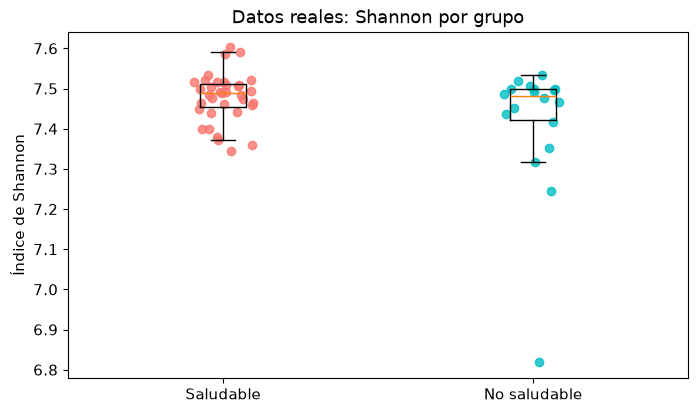

In [16]:
grafica_cajas(x, y, "Índice de Shannon", "Datos reales: Shannon por grupo")

Compara las dos columnas de la tabla:

- En los datos reales el grupo no saludable **no es normal** (Shapiro-Wilk, $p < 0.001$): la planta con un Shannon muy bajo se ve en la figura.
- Las varianzas **son muy distintas** (prueba F, $p < 0.001$): la del grupo no saludable es más de siete veces mayor.
- Con varianzas iguales el valor p es 0.058, casi significativo; con Welch es 0.150. **Elegir mal el supuesto puede cambiar la conclusión.** Como los datos no cumplen el supuesto de varianzas iguales, el resultado que vale es el de Welch: no hay evidencia de que la diversidad promedio difiera.

¿Y el $p \approx 0.04$ por permutaciones del Episodio 2? Barajar etiquetas supone que bajo $H_0$ los dos grupos tienen la misma distribución. Cuando el grupo pequeño es el más variable, como aquí, tanto la permutación como la t de Student se vuelven demasiado optimistas y dan valores p más pequeños de lo que deberían. **La respuesta correcta no es la de la prueba que da el p más pequeño, sino la de la prueba cuyos supuestos se cumplen.** Esto volverá a aparecer con el PERMANOVA, que también se basa en barajar etiquetas.

Y la prueba F dio algo más interesante que la t: las plantas no saludables **son más variables entre sí**. Eso es un hallazgo en sí mismo.

### ✏️ Ejercicio 3: Repetir la comparación con otro índice

⏱️ *8 min*

Repite el análisis de este episodio con el estimador de riqueza **Chao1** de los datos reales (columna `chao1`):

1. Extrae los valores de cada grupo y aplica `comparar_medias`.
2. Según la prueba F, ¿qué versión de la prueba t corresponde?
3. Escribe la conclusión en una frase.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

Las medias son muy parecidas: 8 768 frente a 8 752 especies estimadas. La prueba F da $p \approx 0.057$, justo por encima de 0.05, así que formalmente no se rechaza la igualdad de varianzas y corresponde la t de Student, que da $p \approx 0.35$. Dos detalles instructivos: con un valor tan cercano al umbral lo prudente es mirar también Welch ($p \approx 0.41$), y el grupo no saludable queda en el límite de la normalidad (Shapiro-Wilk, $p \approx 0.04$), así que conviene confirmar con una prueba de rangos como las del episodio siguiente. Ninguna cambia la conclusión: no hay evidencia de que la riqueza estimada con Chao1 difiera entre plantas saludables y no saludables.

```python
# Chao1 de cada grupo
xc = datos.loc[datos.grupo == "Saludable", "chao1"].to_numpy()
yc = datos.loc[datos.grupo == "No saludable", "chao1"].to_numpy()
# la misma función del episodio, ahora con otro índice
display(pd.DataFrame({"Chao1, datos reales": comparar_medias(xc, yc)}))
```

</details>

> **🔑 Puntos clave**
> - La prueba t compara dos medias: divide la diferencia entre su error estándar.
> - La t de Student supone varianzas iguales; la de Welch no. Ante la duda, Welch es la opción segura.
> - Los supuestos se comprueban antes de mirar el valor p: normalidad (Shapiro-Wilk, gráficos) e igualdad de varianzas (prueba F).
> - Cuando los supuestos se cumplen, las pruebas coinciden. Cuando no, vale la prueba que respeta los datos, no la que da el valor p más pequeño.
> - Que un grupo sea más variable que el otro es un resultado, no solo un problema.

---
## Episodio 4. Pruebas basadas en rangos: Mann-Whitney y Wilcoxon

⏱️ **Explicación: 15 min · Ejercicios: 6 min**

> **❓ Preguntas**
> - ¿Qué hago cuando los datos no son normales o hay valores atípicos?
> - ¿En qué se diferencian la prueba de Mann-Whitney y la de Wilcoxon de rangos con signo?
>
> **🎯 Objetivos**
> - Explicar qué significa trabajar con rangos y por qué resiste los valores atípicos.
> - Aplicar Mann-Whitney a dos grupos independientes e interpretar su estadístico U.
> - Aplicar Wilcoxon de rangos con signo a datos pareados.
> - Decidir cuál de las dos corresponde según el diseño del estudio.

**Qué hacemos.** Cuando los datos no son normales, como el grupo no saludable real, se usan pruebas **basadas en rangos**: se ordenan todos los valores de menor a mayor y se trabaja con sus posiciones, no con los valores.

**Por qué así.** Un valor extremo, como el Shannon de 6.82 de una planta no saludable, pesa muchísimo en una media. En una lista ordenada es simplemente «el más pequeño»: su rango es 1, esté lejos o cerca del siguiente. Por eso las pruebas de rangos resisten los valores atípicos y no suponen normalidad.

Hay dos pruebas con el nombre de Wilcoxon y se confunden con frecuencia:

| Prueba | Nombres | Para qué sirve | Función en scipy |
|---|---|---|---|
| **Suma de rangos** | Wilcoxon rank-sum, Mann-Whitney U | Dos grupos **independientes** (plantas saludables y no saludables) | `stats.mannwhitneyu` |
| **Rangos con signo** | Wilcoxon signed-rank | Dos medidas **pareadas** sobre las mismas unidades (antes y después, o dos índices de la misma muestra) | `stats.wilcoxon` |

Para comparar los dos grupos de plantas la correcta es **Mann-Whitney**. Su estadístico $U$ cuenta en cuántos pares (una muestra saludable, una no saludable) el valor mayor es el de la saludable. Si los grupos fueran iguales, $U$ estaría cerca de la mitad de los pares posibles.

### 4.1 Caso ideal

Mann-Whitney, datos simulados: U = 647 (de 900 pares), p = 0.0032


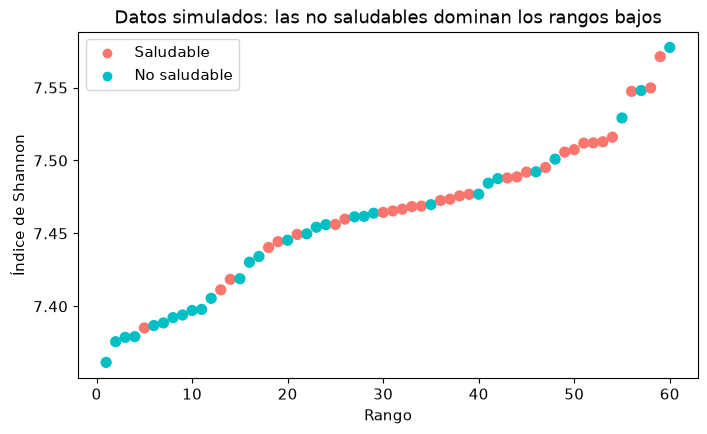

In [17]:
def grafica_rangos(tabla, variable, etiqueta_y, titulo):
    "Valores de una variable ordenados de menor a mayor (su rango), coloreados por grupo."
    orden = tabla.sort_values(variable)                 # muestras de menor a mayor
    fig, ax = plt.subplots()
    # eje x = rango (1, 2, 3...); map(COLORES) convierte el grupo de cada muestra en su color
    ax.scatter(range(1, len(orden) + 1), orden[variable], c=orden.grupo.map(COLORES).tolist(), s=50)
    ax.set_xlabel("Rango"); ax.set_ylabel(etiqueta_y); ax.set_title(titulo)
    for g, c in COLORES.items():
        ax.scatter([], [], color=c, label=g)            # puntos vacíos: solo sirven para armar la leyenda
    ax.legend(); plt.show()

# alternative="two-sided": prueba bilateral (los grupos difieren, sin fijar en qué sentido)
mw_sim = stats.mannwhitneyu(x_sim, y_sim, alternative="two-sided", method="exact")
print(f"Mann-Whitney, datos simulados: U = {mw_sim.statistic:.0f} (de {len(x_sim) * len(y_sim)} pares), p = {mw_sim.pvalue:.4f}")
grafica_rangos(datos_sim, "shannon", "Índice de Shannon", "Datos simulados: las no saludables dominan los rangos bajos")

Los colores tienden a separarse: los rangos bajos son sobre todo de plantas no saludables y los altos, de saludables, aunque en el centro se mezclan. $U$ queda lejos de 450, la mitad de los $30 \times 30 = 900$ pares, y Mann-Whitney coincide con la prueba t.

> 💬 **Para pensar (1 min).** En los datos reales, ¿en qué rango quedará la planta con Shannon de 6.82? ¿Pesará tanto como pesó en la media?

### 4.2 Caso real

Mann-Whitney, datos reales: U = 376 (de 630 pares), p = 0.2586
Nota: R reporta este mismo estadístico con el nombre W = 376.


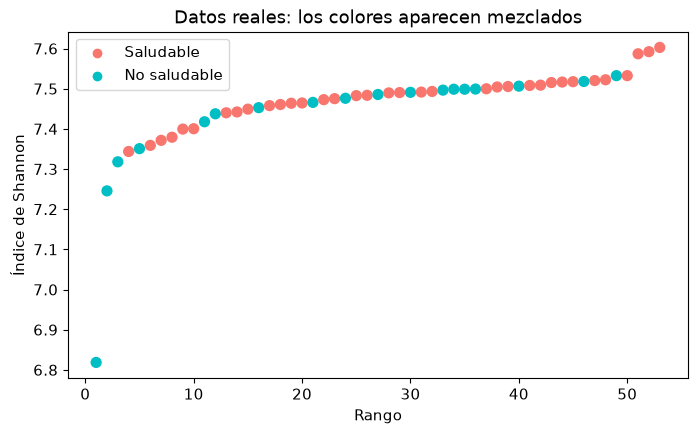

In [18]:
mw = stats.mannwhitneyu(x, y, alternative="two-sided", method="exact")   # "exact" es lo que usa R con n < 50
print(f"Mann-Whitney, datos reales: U = {mw.statistic:.0f} (de {len(x) * len(y)} pares), p = {mw.pvalue:.4f}")
print("Nota: R reporta este mismo estadístico con el nombre W = 376.")
grafica_rangos(datos, "shannon", "Índice de Shannon", "Datos reales: los colores aparecen mezclados")

Los dos colores aparecen mezclados en todo el recorrido y el valor p lo confirma: $U = 376$ está cerca de 315, la mitad de los $35 \times 18 = 630$ pares. Mann-Whitney coincide con Welch. La planta atípica ocupa el rango 1 y no pesa más que cualquier otra.

### 4.3 ¿Y la de rangos con signo?

Solo tiene sentido con **datos pareados**. Un ejemplo legítimo con los datos reales: para cada una de las 53 muestras tenemos dos medidas de la misma cosa, el Shannon calculado sobre toda la tabla de géneros y el Shannon calculado solo sobre los géneros bacterianos. ¿Difieren? Aquí cada muestra es su propio control, así que la prueba correcta es la de rangos con signo.

In [19]:
# apply(shannon) aplica la función a cada columna, es decir, a cada muestra;
# xs("Bacteria", level="reino") deja solo las filas cuyo reino es Bacteria
sh_todos    = generos.apply(shannon)                                          # Shannon por muestra, todos los géneros
sh_bacteria = generos.xs("Bacteria", level="reino").apply(shannon)            # solo géneros bacterianos
assert (sh_todos.index == sh_bacteria.index).all()                            # mismas muestras, mismo orden

# la prueba usa las 53 diferencias, una por muestra; H0 = están centradas en cero
w = stats.wilcoxon(sh_todos, sh_bacteria)
print(f"Diferencia mediana (todos - bacterias) = {np.median(sh_todos - sh_bacteria):.4f}")
print(f"Wilcoxon de rangos con signo: W = {w.statistic:.0f}, p = {w.pvalue:.2e}")
print("Aquí sí hay diferencia: quitar los eucariotas cambia el Shannon de cada muestra de forma sistemática.")

Diferencia mediana (todos - bacterias) = 0.0263
Wilcoxon de rangos con signo: W = 0, p = 2.39e-10
Aquí sí hay diferencia: quitar los eucariotas cambia el Shannon de cada muestra de forma sistemática.


### ✏️ Ejercicio 4: ¿Independientes o pareados?

⏱️ *6 min*

Para cada situación, di qué prueba corresponde (Mann-Whitney o Wilcoxon de rangos con signo) y por qué:

1. Comparar la riqueza observada (`observados`) entre plantas saludables y no saludables.
2. Comparar, en las mismas 53 muestras, el índice de Simpson con el de Shannon.
3. Comparar el porcentaje de *Fusarium* en 10 plantas antes y después de aplicar un biocontrol.

Después, aplica la prueba del punto 1 con código.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. **Mann-Whitney**: son dos grupos de plantas distintas, independientes.
2. **Rangos con signo**: son dos medidas sobre las mismas muestras. Aunque en este caso la comparación tiene poco sentido biológico, porque los dos índices están en escalas diferentes.
3. **Rangos con signo**: cada planta se mide dos veces; el par es la planta.

Para el punto 1, el valor p es alto: la riqueza observada tampoco distingue a los grupos.

```python
# Riqueza observada de cada grupo: son plantas distintas, así que corresponde Mann-Whitney
xo = datos.loc[datos.grupo == "Saludable", "observados"]
yo = datos.loc[datos.grupo == "No saludable", "observados"]
r = stats.mannwhitneyu(xo, yo, alternative="two-sided", method="exact")
print(f"U = {r.statistic:.0f}, p = {r.pvalue:.4f}")
```

</details>

> **🔑 Puntos clave**
> - Las pruebas de rangos trabajan con el orden de los valores, no con los valores: no suponen normalidad y resisten los atípicos.
> - Mann-Whitney compara dos grupos independientes; su estadístico U cuenta en cuántos pares gana un grupo.
> - Wilcoxon de rangos con signo es para datos pareados: dos medidas de las mismas unidades.
> - La prueba se elige por el diseño del estudio (independientes o pareados), no por el nombre.

---
## Episodio 5. Un género de interés: ¿es más abundante en un grupo?

⏱️ **Explicación: 10 min · Ejercicios: 10 min**

> **❓ Preguntas**
> - ¿Cómo comparo la abundancia de un taxón entre dos grupos?
> - ¿Por qué un resultado no significativo no descarta una relación biológica?
>
> **🎯 Objetivos**
> - Calcular la proporción de lecturas de un género con el denominador correcto.
> - Comparar esa proporción entre grupos con la prueba de Mann-Whitney.
> - Reconocer el efecto de la composicionalidad y el problema de las comparaciones múltiples.

**Qué hacemos.** Hasta ahora comparamos un índice que resume toda la comunidad. Otra pregunta frecuente es más concreta: **¿un taxón en particular es más abundante en un grupo?** Calculamos, para cada muestra, el porcentaje de sus lecturas que pertenece a ese taxón y comparamos los porcentajes entre grupos.

**Por qué así.** Se comparan porcentajes y no conteos porque cada muestra tiene un número distinto de lecturas. Y como un porcentaje no suele ser normal (está acotado entre 0 y 100 y con frecuencia es asimétrico), usamos **Mann-Whitney**.

Dos cuidados:

- **El denominador.** Se divide entre **todas** las lecturas clasificadas de la muestra, no solo entre las que tienen género asignado.
- **La composicionalidad.** Los porcentajes de una muestra suman 100, así que el aumento de un taxón puede deberse a que otros bajaron.

### 5.1 Caso ideal: un género que de verdad cambia

,mean,median,min,max
grupo,,,,
No saludable,14.85,14.07,9.66,22.60
Saludable,4.78,4.60,2.17,8.14


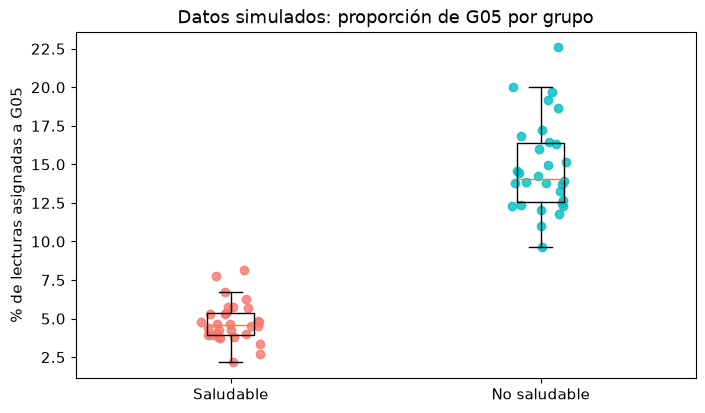

Mann-Whitney sobre % de G05: U = 0 (de 900 pares), p = 1.7e-17


In [20]:
# Lecturas del género que simulamos como patógeno (G05) en cada muestra
pat = generos_sim.loc[patogeno]
assert (pat.index == datos_sim.index).all()                      # emparejadas por identificador
# porcentaje sobre todas las lecturas de la muestra; queda como columna nueva de datos_sim
datos_sim["patogeno_pct"] = 100 * pat / generos_sim.sum(axis=0)

# agg calcula varios resúmenes a la vez para cada grupo
display(datos_sim.groupby("grupo").patogeno_pct.agg(["mean", "median", "min", "max"]).round(2))

xp = datos_sim.loc[datos_sim.grupo == "Saludable", "patogeno_pct"]      # % de G05 en las saludables
yp = datos_sim.loc[datos_sim.grupo == "No saludable", "patogeno_pct"]   # % de G05 en las no saludables
grafica_cajas(xp, yp, "% de lecturas asignadas a G05", "Datos simulados: proporción de G05 por grupo")

# Mann-Whitney: dos grupos independientes y una variable que no tiene por qué ser normal
mw_pat = stats.mannwhitneyu(xp, yp, alternative="two-sided", method="exact")
print(f"Mann-Whitney sobre % de G05: U = {mw_pat.statistic:.0f} (de {len(xp) * len(yp)} pares), p = {mw_pat.pvalue:.1e}")

Así se ve un taxón que realmente difiere: las cajas no se superponen, $U = 0$ (en ningún par gana una planta saludable) y el valor p es minúsculo. `G05` pasa de cerca del 5 % al 15 % de las lecturas, muy cerca de lo que simulamos.

> 💬 **Para pensar (1 min).** *Fusarium* es un género de hongos que incluye a los causantes de la marchitez de la fresa. Si las plantas no saludables están enfermas por *Fusarium*, ¿qué esperas ver en los datos reales?

### 5.2 Caso real: *Fusarium*

Calculamos, para cada muestra real, el porcentaje de lecturas clasificadas que pertenecen a *Fusarium*.

,mean,median,min,max
grupo,,,,
No saludable,0.151,0.127,0.065,0.387
Saludable,0.136,0.119,0.070,0.234


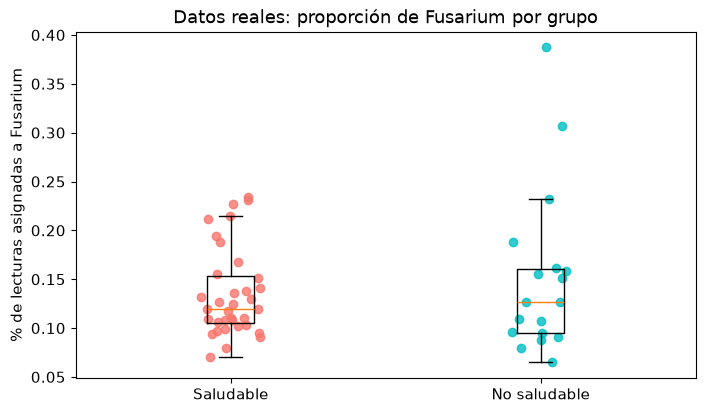

Mann-Whitney sobre % de Fusarium: U = 317 (de 630 pares), p = 0.9777


In [21]:
# xs("Fusarium", level="genero") selecciona la fila de ese género;
# iloc[0] la deja como una serie con un valor por muestra
fus = generos.xs("Fusarium", level="genero").iloc[0]            # lecturas de Fusarium por muestra
assert (fus.index == datos.index).all()                          # emparejadas por identificador
# porcentaje sobre TODAS las lecturas clasificadas de la muestra; queda como columna nueva de datos
datos["fusarium_pct"] = 100 * fus / datos.lecturas_clasificadas

display(datos.groupby("grupo").fusarium_pct.agg(["mean", "median", "min", "max"]).round(3))

xf = datos.loc[datos.grupo == "Saludable", "fusarium_pct"]      # % de Fusarium en las saludables
yf = datos.loc[datos.grupo == "No saludable", "fusarium_pct"]   # % de Fusarium en las no saludables
grafica_cajas(xf, yf, "% de lecturas asignadas a Fusarium", "Datos reales: proporción de Fusarium por grupo")

mwf = stats.mannwhitneyu(xf, yf, alternative="two-sided", method="exact")
print(f"Mann-Whitney sobre % de Fusarium: U = {mwf.statistic:.0f} (de {len(xf) * len(yf)} pares), p = {mwf.pvalue:.4f}")

*Fusarium* representa en promedio alrededor del 0.14 % de las lecturas en ambos grupos, con una superposición casi total y sin diferencia significativa: $U = 317$ es prácticamente la mitad de los 630 pares. ¿Significa que *Fusarium* no tiene que ver con la enfermedad? No necesariamente:

- Kraken asigna lecturas al **género**; no distingue las cepas patógenas de las inocuas.
- Un porcentaje puede bajar aunque el número de células suba, si otros taxones subieron más.
- Con 18 plantas no saludables, la potencia para detectar diferencias pequeñas es baja.

**Una lección de este análisis.** Una versión anterior reportaba una diferencia muy significativa (p = 0.0017) en la diversidad de los géneros eucariotas, el grupo que contiene a *Fusarium*. Era un error: el script unía la tabla de diversidad con los metadatos **por posición**, y como una de las dos tablas estaba ordenada de otra manera, cada valor quedó asignado al grupo de otra muestra. Por eso en este taller hay un `assert` cada vez que se unen tablas. Comprobar que los identificadores coinciden toma un segundo y evita un resultado falso con un valor p muy convincente.

### ✏️ Ejercicio 5: Otros géneros candidatos

⏱️ *10 min*

Escribe una función `porcentaje(genero)` que devuelva el porcentaje de lecturas de ese género en cada muestra real, y úsala para comparar entre grupos, con Mann-Whitney, estos tres géneros:

- *Phytophthora* (oomiceto patógeno de la fresa),
- *Ralstonia* (bacteria que causa marchitez),
- *Streptomyces* (bacteria benéfica, la más abundante).

¿Alguno difiere significativamente? Si hicieras esta prueba para los 1 795 géneros, ¿qué problema tendrías?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

*Ralstonia* y *Streptomyces* no difieren. *Phytophthora* sí sale significativo ($p \approx 0.013$), pero mira la dirección: es ligeramente **más** abundante en las plantas saludables (0.060 % frente a 0.055 %), lo contrario de lo que esperaríamos de un patógeno. Antes de celebrarlo, piensa en esto: acabamos de hacer tres pruebas, y en el taller llevamos ya más de diez. Si probáramos los 1 795 géneros, por puro azar unos 90 saldrían «significativos» con p < 0.05 aunque ningún género difiriera de verdad. Eso se llama el problema de las **comparaciones múltiples**, y se corrige ajustando los valores p, por ejemplo con el método de Benjamini-Hochberg (`statsmodels.stats.multitest.multipletests`). Con esa corrección, el resultado de *Phytophthora* no sobrevive. Un p aislado de 0.013 entre muchas pruebas es una hipótesis para un estudio nuevo, no un hallazgo.

```python
def porcentaje(genero):
    "Porcentaje de las lecturas clasificadas de cada muestra que pertenecen a ese género."
    lecturas = generos.xs(genero, level="genero").sum(axis=0)   # sum: por si el género aparece en más de un filo
    return 100 * lecturas / datos.lecturas_clasificadas

for g in ["Phytophthora", "Ralstonia", "Streptomyces"]:
    v = porcentaje(g)
    # a = porcentajes de las saludables, b = de las no saludables
    a, b = v[datos.grupo == "Saludable"], v[datos.grupo == "No saludable"]
    r = stats.mannwhitneyu(a, b, alternative="two-sided", method="exact")
    print(f"{g:14s} media sal = {a.mean():.3f}%  media no sal = {b.mean():.3f}%  p = {r.pvalue:.3f}")
```

</details>

> **🔑 Puntos clave**
> - La abundancia de un taxón se compara como proporción de las lecturas de cada muestra, cuidando el denominador.
> - Los datos son composicionales: una proporción puede cambiar porque cambiaron las demás.
> - No encontrar diferencia no descarta una relación biológica: influyen la resolución taxonómica y el tamaño de muestra.
> - Cuantas más pruebas se hacen, más resultados «significativos» aparecen por azar: hay que corregir por comparaciones múltiples.

---
## Episodio 6. Comparar la composición completa: PERMANOVA y PERMDISP

⏱️ **Explicación: 25 min · Ejercicios: 10 min**

> **❓ Preguntas**
> - ¿Cómo comparo comunidades enteras y no un solo número por muestra?
> - ¿Qué mide el PERMANOVA y por qué debe acompañarse de PERMDISP?
>
> **🎯 Objetivos**
> - Calcular la disimilitud de Bray-Curtis entre muestras.
> - Programar el pseudo-F del PERMANOVA y obtener su valor p por permutaciones.
> - Evaluar con PERMDISP si los grupos difieren en dispersión.
> - Interpretar los dos resultados en conjunto, con ayuda de una ordenación.

Hasta ahora comparamos **un número por muestra**: Shannon, Chao1, el porcentaje de un género. Pero una muestra es en realidad un vector de abundancias: 40 en los datos simulados, 1 795 en los reales. ¿Cómo se comparan vectores entre grupos?

**Qué hacemos**, en tres pasos:

**Paso 1: una distancia entre muestras.** Usamos la disimilitud de **Bray-Curtis**, calculada sobre abundancias relativas:

$$d_{BC}(x, y) = \frac{\sum_i |x_i - y_i|}{\sum_i (x_i + y_i)}$$

Vale 0 si dos muestras tienen la misma composición y 1 si no comparten ningún taxón.

**Paso 2: un estadístico.** El PERMANOVA (Anderson, 2001) reparte la variación total entre muestras en dos partes, la que hay **entre** grupos y la que hay **dentro** de los grupos, y forma un cociente llamado pseudo-F, igual que el ANOVA clásico. Si el grupo no importa, el pseudo-F es cercano a 1.

**Paso 3: el valor p por permutaciones.** Igual que en el Episodio 2: se barajan las etiquetas de grupo muchas veces, se recalcula el pseudo-F y se cuenta cuántas veces supera al observado.

**Por qué así.** No hay una «prueba t para vectores» que funcione con cientos de taxones, pocas muestras y distribuciones tan poco normales. Trabajar con distancias y permutaciones evita suponer una distribución.

Lo programamos a mano, en pocas líneas, para que no sea una caja negra.

### 6.1 Paso 1: de la tabla de conteos a una matriz de distancias

In [22]:
# Datos simulados: abundancias relativas y matriz de distancias (60 x 60)
# cada columna (muestra) se divide entre su total; .T traspone la tabla para dejar las muestras en filas
rel_sim = (generos_sim / generos_sim.sum(axis=0)).T      # filas = muestras, columnas = géneros, cada fila suma 1
assert np.allclose(rel_sim.sum(axis=1), 1)               # comprobación: cada fila suma 1
# pdist calcula la distancia de cada par de muestras; squareform las acomoda en una matriz cuadrada simétrica
D_sim = squareform(pdist(rel_sim.to_numpy(), metric="braycurtis"))

# comprobación con la fórmula a mano para el primer par de muestras
a, b = rel_sim.iloc[0].to_numpy(), rel_sim.iloc[1].to_numpy()
print("Bray-Curtis a mano:", round(np.abs(a - b).sum() / (a + b).sum(), 4), "| scipy:", round(D_sim[0, 1], 4))

# Datos reales: los mismos pasos (53 x 53)
rel = (generos / generos.sum(axis=0)).T
assert np.allclose(rel.sum(axis=1), 1)
D = squareform(pdist(rel.to_numpy(), metric="braycurtis"))

# Grupo de cada muestra, en el mismo orden que las filas de cada matriz
etiquetas_sim = datos_sim.grupo.to_numpy()
etiquetas = datos.grupo.to_numpy()
print("Matrices de distancias:", D_sim.shape, "simulados |", D.shape, "reales")

Bray-Curtis a mano: 0.1472 | scipy: 0.1472
Matrices de distancias: (60, 60) simulados | (53, 53) reales


### 6.2 Paso 2: el pseudo-F

In [23]:
def pseudo_F(D, etiquetas):
    "Pseudo-F y R2 del PERMANOVA a partir de la matriz de distancias y el grupo de cada muestra."
    n = len(etiquetas)
    grupos = np.unique(etiquetas)
    # variación total: distancias al cuadrado de todos los pares, entre n
    # (D es simétrica y cuenta cada par dos veces: por eso el 2)
    SS_total = (D ** 2).sum() / (2 * n)
    # variación dentro de los grupos: lo mismo, solo con los pares de un mismo grupo
    # (np.ix_ recorta de D el bloque de filas y columnas del grupo g)
    SS_dentro = sum((D[np.ix_(etiquetas == g, etiquetas == g)] ** 2).sum() / (2 * (etiquetas == g).sum())
                    for g in grupos)
    SS_entre = SS_total - SS_dentro     # lo que queda es la variación entre grupos
    # cada suma de cuadrados se divide entre sus grados de libertad, como en el ANOVA
    F = (SS_entre / (len(grupos) - 1)) / (SS_dentro / (n - len(grupos)))
    R2 = SS_entre / SS_total            # fracción de la variación que explica el grupo
    return F, R2

for caso, matriz, grupo in [("Datos simulados", D_sim, etiquetas_sim), ("Datos reales", D, etiquetas)]:
    F_caso, R2_caso = pseudo_F(matriz, grupo)
    print(f"{caso:16s}: pseudo-F = {F_caso:6.3f}   R2 = {R2_caso:.4f}  (el grupo explica el {100 * R2_caso:.1f} % de la variación)")

Datos simulados : pseudo-F = 22.857   R2 = 0.2827  (el grupo explica el 28.3 % de la variación)
Datos reales    : pseudo-F =  1.142   R2 = 0.0219  (el grupo explica el 2.2 % de la variación)


En los datos simulados el grupo explica cerca del 28 % de la variación; en los reales, el 2 %. Falta saber si esos valores son mayores de lo que produce el azar.

### 6.3 Paso 3: el valor p por permutaciones

PERMANOVA, datos simulados (999 permutaciones): pseudo-F = 22.857, R2 = 0.2827, p = 0.001


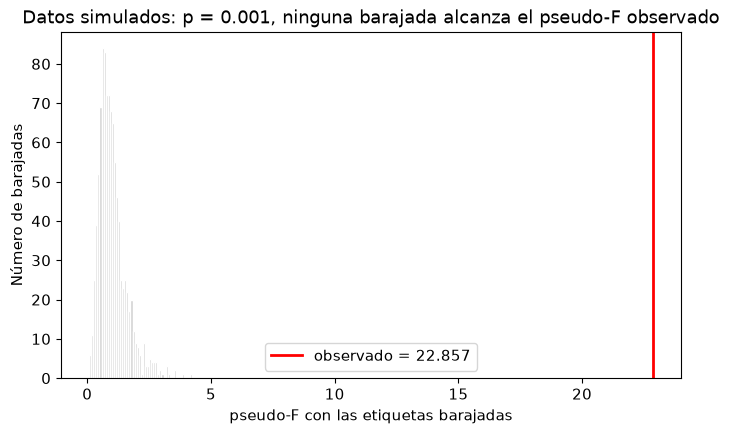

In [24]:
def permanova(D, etiquetas, n_perm=999, semilla=2026):
    "PERMANOVA: devuelve el pseudo-F observado, el R2, el valor p y los pseudo-F de las permutaciones."
    rng = np.random.default_rng(semilla)
    F_obs, R2 = pseudo_F(D, etiquetas)                      # estadístico con las etiquetas reales
    # se barajan las etiquetas n_perm veces y se guarda el pseudo-F de cada barajada ([0] toma F y deja R2)
    F_perm = np.array([pseudo_F(D, rng.permutation(etiquetas))[0] for _ in range(n_perm)])
    p = (np.sum(F_perm >= F_obs) + 1) / (n_perm + 1)        # +1: la observación cuenta como una permutación
    return F_obs, R2, p, F_perm

F_obs_sim, R2_sim, p_sim, F_perm_sim = permanova(D_sim, etiquetas_sim)
print(f"PERMANOVA, datos simulados (999 permutaciones): pseudo-F = {F_obs_sim:.3f}, R2 = {R2_sim:.4f}, p = {p_sim:.3f}")
# bilateral=False: solo cuentan los pseudo-F mayores que el observado
grafica_nula(F_perm_sim, F_obs_sim, "pseudo-F con las etiquetas barajadas",
             f"Datos simulados: p = {p_sim:.3f}, ninguna barajada alcanza el pseudo-F observado", bilateral=False)

> 💬 **Para pensar (1 min).** En los datos reales el grupo explica el 2 % de la variación. ¿Dónde crees que caerá el pseudo-F observado dentro del histograma: en el centro o en la cola?

PERMANOVA, datos reales (999 permutaciones): pseudo-F = 1.142, R2 = 0.0219, p = 0.282


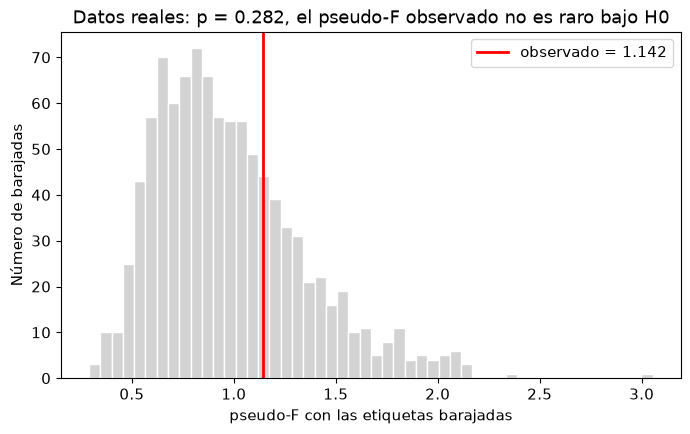

In [25]:
F_obs, R2, p, F_perm = permanova(D, etiquetas)
print(f"PERMANOVA, datos reales (999 permutaciones): pseudo-F = {F_obs:.3f}, R2 = {R2:.4f}, p = {p:.3f}")
grafica_nula(F_perm, F_obs, "pseudo-F con las etiquetas barajadas",
             f"Datos reales: p = {p:.3f}, el pseudo-F observado no es raro bajo H0", bilateral=False)

En los datos simulados ninguna de las 999 barajadas alcanza el pseudo-F observado: $p = 0.001$, el valor más pequeño posible con 999 permutaciones. En los datos reales el estado de la planta explica alrededor del 2 % de la variación en la composición, y ese 2 % no se distingue de lo que produce el azar. Calculado sobre los 9 003 taxones en lugar de los géneros, la conclusión es la misma: $R^2 = 0.024$, $p = 0.20$.

### 6.4 Una advertencia que casi siempre se olvida: la dispersión

El PERMANOVA también reacciona cuando un grupo es **más disperso** que el otro, aunque sus centros coincidan. Con grupos desbalanceados (35 contra 18) esto importa. Por eso se acompaña con **PERMDISP**: se calcula la distancia de cada muestra al centro de su grupo y se comprueba si esas distancias difieren entre grupos. Si PERMDISP sale significativo, un PERMANOVA significativo podría deberse a la dispersión y no a la composición promedio.

In [26]:
def pcoa(D):
    "Coordenadas principales a partir de una matriz de distancias; las primeras columnas recogen más variación."
    n = D.shape[0]
    A = -0.5 * D ** 2                          # -1/2 por las distancias al cuadrado
    J = np.eye(n) - np.ones((n, n)) / n        # matriz de centrado
    B = J @ A @ J                              # doble centrado: resta las medias de filas y de columnas
    val, vec = np.linalg.eigh(B)               # valores y vectores propios (B es simétrica), de menor a mayor
    val, vec = val[::-1], vec[:, ::-1]         # se invierte el orden: primero los ejes más importantes
    keep = val > 1e-10                         # se descartan los valores propios nulos o negativos
    return vec[:, keep] * np.sqrt(val[keep])   # coordenadas: vector propio por la raíz de su valor propio

def permdisp(D, etiquetas, n_perm=999, semilla=2026):
    "PERMDISP: compara entre grupos la distancia de cada muestra al centroide de su grupo."
    coords = pcoa(D)
    dist_centro = np.empty(len(etiquetas))     # aquí va la distancia de cada muestra a su centroide
    for g in np.unique(etiquetas):
        m = etiquetas == g                     # máscara: True en las muestras del grupo g
        centro = coords[m].mean(axis=0)        # centroide: promedio de las coordenadas del grupo
        # distancia euclidiana de cada muestra del grupo a ese centroide
        dist_centro[m] = np.sqrt(((coords[m] - centro) ** 2).sum(axis=1))
    grupos = [dist_centro[etiquetas == g] for g in np.unique(etiquetas)]
    F_obs = stats.f_oneway(*grupos).statistic  # ANOVA de una vía sobre esas distancias
    rng = np.random.default_rng(semilla)
    # valor p por permutaciones: se barajan las etiquetas y se repite el ANOVA
    F_perm = [stats.f_oneway(*[dist_centro[rng.permutation(etiquetas) == g] for g in np.unique(etiquetas)]).statistic
              for _ in range(n_perm)]
    p = (np.sum(np.array(F_perm) >= F_obs) + 1) / (n_perm + 1)
    return dist_centro, F_obs, p

for caso, matriz, grupo in [("Datos simulados", D_sim, etiquetas_sim), ("Datos reales", D, etiquetas)]:
    dist_centro, F_disp, p_disp = permdisp(matriz, grupo)
    print(caso)
    for g in GRUPOS:
        print(f"   distancia media al centroide, {g:13s}: {dist_centro[grupo == g].mean():.4f}")
    print(f"   PERMDISP: F = {F_disp:.3f}, p = {p_disp:.3f}")

Datos simulados
   distancia media al centroide, Saludable    : 0.1036
   distancia media al centroide, No saludable : 0.1052
   PERMDISP: F = 0.095, p = 0.654


Datos reales
   distancia media al centroide, Saludable    : 0.0690
   distancia media al centroide, No saludable : 0.0916
   PERMDISP: F = 4.939, p = 0.005


### 6.5 Ver para entender: una ordenación

Una ordenación (aquí, un análisis de coordenadas principales o PCoA) dibuja las muestras en un plano de modo que las distancias en el dibujo se parezcan lo más posible a las de Bray-Curtis. No es una prueba: es la figura que acompaña al PERMANOVA y al PERMDISP.

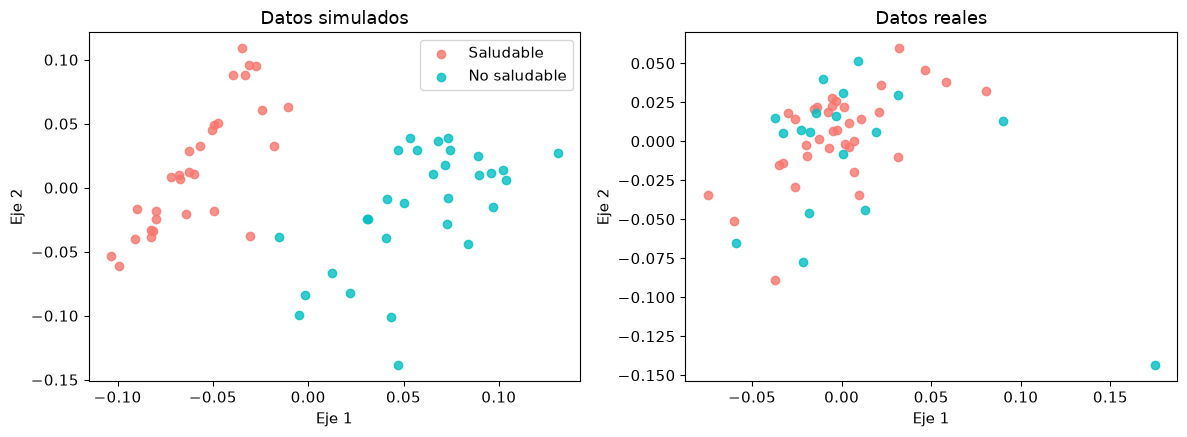

In [27]:
# Un panel por caso: las dos primeras coordenadas principales de cada muestra, coloreadas por grupo
fig, paneles = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (caso, matriz, grupo) in zip(paneles, [("Datos simulados", D_sim, etiquetas_sim), ("Datos reales", D, etiquetas)]):
    coords = pcoa(matriz)                                # columna 0 = eje 1, columna 1 = eje 2
    for g in GRUPOS:
        ax.scatter(coords[grupo == g, 0], coords[grupo == g, 1], color=COLORES[g], label=g, alpha=0.8)
    ax.set_xlabel("Eje 1"); ax.set_ylabel("Eje 2"); ax.set_title(caso)
paneles[0].legend()
fig.tight_layout()                                       # acomoda los paneles para que los rótulos no se monten
plt.show()

**Datos simulados:** dos nubes separadas y de tamaño parecido. PERMANOVA significativo y PERMDISP no significativo: los grupos difieren en su **composición promedio**, no en cuánto varían. Es la situación en la que un PERMANOVA se interpreta sin reservas.

**Datos reales:** las nubes se superponen y la de las plantas no saludables es más amplia. Esas plantas están, en promedio, más lejos de su centroide (0.092 frente a 0.069) y PERMDISP lo confirma con $p \approx 0.005$: **son más heterogéneas en composición**, igual que lo eran en Shannon. Ese es el patrón que hay que reportar junto con el PERMANOVA: los grupos no difieren en su composición promedio, pero sí en cuánto varían. Es el resultado estadísticamente más sólido de los datos reales.

### ✏️ Ejercicio 6: Cambiar la distancia y el nivel taxonómico

⏱️ *10 min*

Con los datos reales:

1. Repite el PERMANOVA usando la distancia de **Jaccard binaria** (presencia/ausencia): `pdist(rel.to_numpy() > 0, metric="jaccard")`. ¿Cambia la conclusión?
2. Repite el PERMANOVA usando **solo los géneros de eucariotas** (`generos.xs("Eukaryota", level="reino")`). ¿El estado de la planta explica más variación en esa fracción?
3. ¿Qué pasa con el valor p si usas 99 permutaciones en vez de 999? Córrelo tres veces con semillas distintas.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. Con Jaccard binaria el $R^2$ sube a cerca del 4 % y el valor p baja a 0.12, pero sigue sin ser significativo. La presencia o ausencia de géneros tampoco separa a los grupos.
2. En los eucariotas el $R^2$ es algo mayor (2.5 %), porque hay solo 58 géneros y cada uno pesa más, pero el valor p (0.22) sigue sin ser significativo.
3. Con 99 permutaciones el valor p solo puede tomar valores en múltiplos de 0.01 y varía bastante entre semillas. Con 999 la variación es de milésimas. Por eso lo habitual es usar al menos 999.

```python
# 1. Jaccard binaria
# rel > 0 convierte las abundancias en presencia o ausencia (True o False)
Dj = squareform(pdist(rel.to_numpy() > 0, metric="jaccard"))
F_j, R2_j, p_j = permanova(Dj, etiquetas)[:3]     # [:3] = pseudo-F, R2 y valor p
print(f"Jaccard:    pseudo-F = {F_j:.2f}, R2 = {R2_j:.3f}, p = {p_j:.3f}")

# 2. Solo eucariotas
euk = generos.xs("Eukaryota", level="reino")
rel_e = (euk / euk.sum(axis=0)).T   # abundancias relativas dentro de los eucariotas
De = squareform(pdist(rel_e.to_numpy(), metric="braycurtis"))
F_e, R2_e, p_e = permanova(De, etiquetas)[:3]
print(f"Eucariotas: pseudo-F = {F_e:.2f}, R2 = {R2_e:.3f}, p = {p_e:.3f}")

# 3. Pocas permutaciones
for s in (1, 2, 3):
    # [2] es el valor p: con 99 permutaciones cambia bastante de una semilla a otra
    print("99 permutaciones, semilla", s, "-> p =", round(permanova(D, etiquetas, n_perm=99, semilla=s)[2], 3))
```

</details>

> **🔑 Puntos clave**
> - Para comparar comunidades completas se trabaja con distancias entre muestras, como la de Bray-Curtis.
> - El PERMANOVA reparte la variación en «entre grupos» y «dentro de los grupos», y obtiene su valor p barajando etiquetas.
> - El R² dice cuánta variación explica el grupo: es el tamaño del efecto y se reporta siempre.
> - El PERMANOVA también reacciona a diferencias de dispersión: se acompaña con PERMDISP y con una ordenación.

---
## Episodio 7. Cierre: reportar y comparar los dos casos

⏱️ **Explicación: 10 min · Ejercicios: 8 min**

> **❓ Preguntas**
> - ¿Cómo se presentan los resultados de varias pruebas?
> - ¿Qué enseña poner un caso ideal junto a uno real?
>
> **🎯 Objetivos**
> - Reunir en una tabla el estadístico y el valor p de cada prueba.
> - Elegir la prueba adecuada según la pregunta, el diseño y los supuestos.
> - Redactar un resultado justificando la prueba elegida.

Reunimos todas las pruebas en una tabla, que es la forma en que se presentan en un informe o en un artículo: cada prueba con su estadístico y su valor p, y los dos casos lado a lado. La función siguiente repite, para un caso, todas las pruebas del taller con las funciones que ya escribimos.

> 💬 **Para pensar (1 min).** Antes de ejecutar: ¿en cuál de los dos casos esperas que todas las pruebas sobre el índice de Shannon coincidan? ¿Por qué?

In [28]:
def todas_las_pruebas(x, y, pct_x, pct_y, D, etiquetas):
    "Repite las pruebas del taller para un caso: devuelve el estadístico y el valor p de cada una."
    dif, _, p_perm = prueba_permutacion(x, y)
    F = x.var(ddof=1) / y.var(ddof=1)
    cola = stats.f.cdf(F, len(x) - 1, len(y) - 1)
    student = stats.ttest_ind(x, y, equal_var=True)
    welch = stats.ttest_ind(x, y, equal_var=False)
    mw_indice = stats.mannwhitneyu(x, y, alternative="two-sided", method="exact")
    mw_genero = stats.mannwhitneyu(pct_x, pct_y, alternative="two-sided", method="exact")
    F_permanova, R2, p_permanova, _ = permanova(D, etiquetas)
    _, F_disp, p_disp = permdisp(D, etiquetas)
    # (variable, prueba): (estadístico, valor p)
    filas = {
        ("Índice de Shannon", "Permutación de medias"):  (f"dif = {dif:.3f}", p_perm),
        ("Índice de Shannon", "F de varianzas"):         (f"F = {F:.3f}", 2 * min(cola, 1 - cola)),
        ("Índice de Shannon", "t de Student"):           (f"t = {student.statistic:.2f}", student.pvalue),
        ("Índice de Shannon", "t de Welch"):             (f"t = {welch.statistic:.2f}", welch.pvalue),
        ("Índice de Shannon", "Mann-Whitney"):           (f"U = {mw_indice.statistic:.0f}", mw_indice.pvalue),
        ("Género de interés (%)", "Mann-Whitney"):       (f"U = {mw_genero.statistic:.0f}", mw_genero.pvalue),
        ("Composición (Bray-Curtis)", "PERMANOVA"):      (f"F = {F_permanova:.2f}, R2 = {R2:.3f}", p_permanova),
        ("Composición (Bray-Curtis)", "PERMDISP"):       (f"F = {F_disp:.2f}", p_disp),
    }
    # una celda de texto por prueba; el asterisco marca los valores p menores que 0.05
    return {clave: f"{est}; p = {formato_p(p)}" + (" *" if p < 0.05 else "") for clave, (est, p) in filas.items()}

sim = todas_las_pruebas(x_sim, y_sim, xp, yp, D_sim, etiquetas_sim)    # género de interés: G05
real = todas_las_pruebas(x, y, xf, yf, D, etiquetas)                   # género de interés: Fusarium
resumen = pd.DataFrame({"Datos simulados (caso ideal)": list(sim.values()), "Datos reales (fresa)": list(real.values())},
                       index=pd.MultiIndex.from_tuples(list(sim.keys()), names=["Variable", "Prueba"]))
display(resumen)
print("* = se rechaza H0 con α = 0.05")

Datos simulados (caso ideal)  \
Variable                  Prueba                                                       
Índice de Shannon         Permutación de medias            dif = 0.037; p = 0.0058 *   
                          F de varianzas                       F = 0.550; p = 0.1128   
                          t de Student                        t = 2.95; p = 0.0046 *   
                          t de Welch                          t = 2.95; p = 0.0047 *   
                          Mann-Whitney                         U = 647; p = 0.0032 *   
Género de interés (%)     Mann-Whitney                          U = 0; p = 1.7e-17 *   
Composición (Bray-Curtis) PERMANOVA              F = 22.86, R2 = 0.283; p = 0.0010 *   
                          PERMDISP                              F = 0.09; p = 0.6540   

                                                             Datos reales (fresa)  
Variable                  Prueba                                                   
Índice de Shannon         Permutación de medias         dif = 0.061; p = 0.0408 *  
                          F de varianzas                 F = 0.132; p = 6.8e-07 *  
                          t de Student                       t = 1.94; p = 0.0581  
                          t de Welch                         t = 1.50; p = 0.1501  
                          Mann-Whitney                        U = 376; p = 0.2586  
Género de interés (%)     Mann-Whitney                        U = 317; p = 0.9777  
Composición (Bray-Curtis) PERMANOVA              F = 1.14, R2 = 0.022; p = 0.2820  
                          PERMDISP                         F = 4.94; p = 0.0050 *

* = se rechaza H0 con α = 0.05


**Lo que muestra el caso ideal.** Todas las pruebas sobre el índice de Shannon coinciden, porque sus supuestos se cumplen: la prueba F no detecta diferencia de varianzas y permutación, Student, Welch y Mann-Whitney dan valores p parecidos. El género que hicimos más abundante se detecta sin dudas, y la composición difiere (PERMANOVA) sin que difiera la dispersión (PERMDISP).

**Lo que muestra el caso real.** La diversidad promedio es un poco mayor en las plantas saludables, pero las pruebas no coinciden ($p = 0.04$, $0.058$, $0.15$ y $0.26$) porque los supuestos fallan. Las que respetan los datos, Welch y Mann-Whitney, no encuentran diferencia. Lo que sí es sólido es que las plantas no saludables **son más variables entre sí**, tanto en diversidad (prueba F) como en composición (PERMDISP). El estado de la planta explica solo un 2 % de la variación en la composición y la proporción de *Fusarium* no difiere.

**Lo que enseña verlos juntos.** La diferencia observada entre las medias era mayor en los datos reales (0.061) que en los simulados (0.037), y aun así solo en los simulados es clara. Un valor p no mide el tamaño de una diferencia: mide qué tan compatible es con el azar, dada la variabilidad y el número de muestras.

### ¿Qué prueba uso?

| Pregunta | Diseño y supuestos | Prueba | En este cuaderno |
|---|---|---|---|
| ¿Difieren las medias de un índice? | Dos grupos independientes, normales, varianzas iguales | t de Student | `stats.ttest_ind(x, y)` |
| ¿Difieren las medias de un índice? | Dos grupos independientes, normales, varianzas distintas o en duda | t de Welch | `stats.ttest_ind(x, y, equal_var=False)` |
| ¿Un grupo tiende a tener valores mayores? | Dos grupos independientes, sin suponer normalidad | Mann-Whitney | `stats.mannwhitneyu(x, y)` |
| ¿Cambia una medida dentro de las mismas muestras? | Datos pareados | Wilcoxon de rangos con signo | `stats.wilcoxon(a, b)` |
| ¿Difiere la composición completa? | Matriz de distancias; dispersiones parecidas | PERMANOVA | `permanova(D, etiquetas)` |
| ¿Difiere la variabilidad de la composición? | Matriz de distancias | PERMDISP | `permdisp(D, etiquetas)` |

En todos los casos: se elige la prueba **antes** de ver los valores p, se comprueban sus supuestos y se reporta el tamaño del efecto (diferencia de medias, $R^2$) junto con el estadístico y el valor p.

### ✏️ Ejercicio 7: Redactar el resultado

⏱️ *8 min*

Escribe, en un párrafo de no más de cinco frases, el resultado de la comparación del índice de Shannon entre grupos en los **datos reales**, como lo pondrías en la sección de resultados de un artículo. Debe incluir: las medias, la prueba usada y por qué, el estadístico con sus grados de libertad, el valor p y la conclusión.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

Un párrafo modelo:

> El índice de Shannon promedio fue de 7.478 en las plantas saludables (n = 35) y de 7.417 en las no saludables (n = 18). Dado que la prueba F rechazó la igualdad de varianzas (F = 0.132, p < 0.001) y el grupo no saludable no cumplió el supuesto de normalidad (Shapiro-Wilk, p < 0.001), se aplicó la prueba t de Welch, que no detectó diferencia entre las medias (t = 1.50, gl = 19.3, p = 0.150), y la prueba de Mann-Whitney, que coincidió (U = 376, p = 0.259). Con el tamaño de muestra disponible no hay evidencia de que la diversidad de Shannon difiera entre grupos, aunque las plantas no saludables presentaron una variabilidad significativamente mayor.

Fíjate en que el párrafo justifica la elección de la prueba, da los números completos y no dice «los grupos son iguales».

</details>

> **🔑 Puntos clave**
> - La prueba se elige según la pregunta, el diseño (independientes o pareados) y los supuestos, antes de ver los valores p.
> - Cuando los supuestos se cumplen, las pruebas coinciden; cuando no coinciden, hay que averiguar qué supuesto falló.
> - Un valor p por permutaciones se construye barajando etiquetas; el PERMANOVA es ese mismo razonamiento con comunidades completas.
> - Se reporta siempre el tamaño del efecto, el estadístico y el valor p, no solo «significativo» o «no significativo».
> - Las tablas se unen por identificador, nunca por posición.

---
## Referencias

**Lecciones de The Carpentries (conocimientos previos)**

- Data Carpentry. (s. f.). *Análisis y visualización de datos usando Python*. https://datacarpentry.github.io/python-ecology-lesson-es/
- Data Carpentry. (s. f.). *Data Analysis and Visualization in Python for Ecologists*. https://datacarpentry.github.io/python-ecology-lesson/
- Software Carpentry. (s. f.). *Plotting and Programming in Python*. https://swcarpentry.github.io/python-novice-gapminder/
- The Carpentries Lab. (s. f.). *Data Processing and Visualization for Metagenomics*. https://carpentries-lab.github.io/metagenomics-analysis/
- The Carpentries Lab. (s. f.). *Metagenomics Workshop Overview*. https://carpentries-lab.github.io/metagenomics-workshop/
- Zirión-Martínez, C., Garfias-Gallegos, D., Arellano-Fernandez, T. V., Espinosa-Jaime, A., Bustos-Díaz, E. D., Lovaco-Flores, J. A., Tejero-Gómez, L. G., Avelar-Rivas, J. A., & Sélem-Mojica, N. (2024). A Data Carpentry-style metagenomics workshop. *Journal of Open Source Education*, 7(72), 209. https://doi.org/10.21105/jose.00209

**Métodos estadísticos**

- Anderson, M. J. (2001). A new method for non-parametric multivariate analysis of variance. *Austral Ecology*, 26(1), 32–46. https://doi.org/10.1111/j.1442-9993.2001.01070.x
- Anderson, M. J. (2006). Distance-based tests for homogeneity of multivariate dispersions. *Biometrics*, 62(1), 245–253. https://doi.org/10.1111/j.1541-0420.2005.00440.x
- Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society: Series B*, 57(1), 289–300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
- Bray, J. R., & Curtis, J. T. (1957). An ordination of the upland forest communities of southern Wisconsin. *Ecological Monographs*, 27(4), 325–349. https://doi.org/10.2307/1942268
- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics*, 18(1), 50–60. https://doi.org/10.1214/aoms/1177730491
- Shannon, C. E. (1948). A mathematical theory of communication. *The Bell System Technical Journal*, 27(3), 379–423. https://doi.org/10.1002/j.1538-7305.1948.tb01338.x
- Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). *Biometrika*, 52(3-4), 591–611. https://doi.org/10.1093/biomet/52.3-4.591
- Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. *Biometrika*, 34(1-2), 28–35. https://doi.org/10.1093/biomet/34.1-2.28
- Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin*, 1(6), 80–83. https://doi.org/10.2307/3001968
- Xia, Y., Sun, J., & Chen, D.-G. (2018). *Statistical Analysis of Microbiome Data with R*. Springer. https://doi.org/10.1007/978-981-13-1534-3

**Datos metagenómicos y composicionalidad**

- Gloor, G. B., Macklaim, J. M., Pawlowsky-Glahn, V., & Egozcue, J. J. (2017). Microbiome datasets are compositional: and this is not optional. *Frontiers in Microbiology*, 8, 2224. https://doi.org/10.3389/fmicb.2017.02224
- McMurdie, P. J., & Holmes, S. (2013). phyloseq: an R package for reproducible interactive analysis and graphics of microbiome census data. *PLoS ONE*, 8(4), e61217. https://doi.org/10.1371/journal.pone.0061217
- Wood, D. E., & Salzberg, S. L. (2014). Kraken: ultrafast metagenomic sequence classification using exact alignments. *Genome Biology*, 15, R46. https://doi.org/10.1186/gb-2014-15-3-r46

**Microbioma de la fresa**

- Siegieda, D., Panek, J., & Frąc, M. (2024). Ecological processes of bacterial microbiome assembly in healthy and dysbiotic strawberry farms. *BMC Plant Biology*, 24. https://doi.org/10.1186/s12870-024-05415-8
- Yang, J., Wei, S., Su, D., et al. (2020). Comparison of the rhizosphere soil microbial community structure and diversity between powdery mildew-infected and noninfected strawberry plants in a greenhouse by high-throughput sequencing technology. *Current Microbiology*, 77, 1724–1736. https://doi.org/10.1007/s00284-020-01948-x
- Zaneveld, J. R., McMinds, R., & Vega Thurber, R. (2017). Stress and stability: applying the Anna Karenina principle to animal microbiomes. *Nature Microbiology*, 2, 17121. https://doi.org/10.1038/nmicrobiol.2017.121

**Software**

- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2
- Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
- Documentación de SciPy: [`ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html), [`mannwhitneyu`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html), [`wilcoxon`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html), [`shapiro`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html).

**Fuente de los datos y del análisis**

- Silva Gómez, P. C. (2026). *Análisis estadístico de la diversidad microbiana a distintos niveles taxonómicos en el microbioma rizosférico de plantas de fresa saludables y no saludables*. Tesis de Maestría en Ciencias Matemáticas, Posgrado Conjunto UMSNH-UNAM. Código y datos: https://github.com/CamilaSilva1995/Tesis_Maestria. Datos metagenómicos facilitados por Solena Ag.
- Solena Ag. (2023). [Metagenomas *shotgun* de la rizósfera de plantas de fresa saludables y no saludables] [Conjunto de datos no publicado]. https://www.solena.ag

---
*Datos facilitados por Solena Ag. Código y datos en [GitHub](https://github.com/CamilaSilva1995/Tesis_Maestria/tree/main/Taller_Practico).*